In [1]:
import pandas as pd
import warnings
warnings.filterwarnings(action='ignore')
df = pd.read_parquet('V2_merge.parquet', engine='fastparquet')

- rfm정의

In [2]:
# 1. RFM 지표 계산
df['t_dat'] = pd.to_datetime(df['t_dat'])
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('t_dat', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 분석에 사용할 컬럼 추출
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 2. 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

- Elbow Method그래프로 군집수 결정

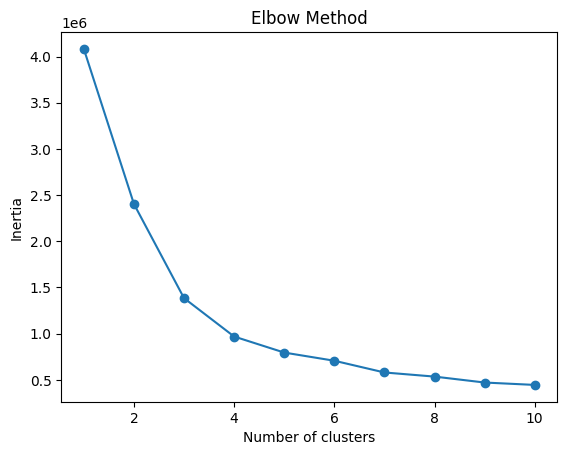

In [4]:
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

- 실루엣 계수(군집검증)

In [5]:
# 통계적 신뢰도 (중심극한정리)
# # Silhouette Score(실루엣 계수)
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 1. 무작위로 10,000개의 인덱스 추출 (130만 건 중 1만 건)
sample_size = 100000
np.random.seed(42) # 결과 재현을 위해 랜덤 시드 고정
indices = np.random.choice(len(rfm_scaled), sample_size, replace=False)

# 2. 추출된 인덱스에 해당하는 데이터만 따로 저장
rfm_scaled_sample = rfm_scaled[indices]

# 3. K=3일 때의 점수 계산
kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels3 = kmeans3.fit_predict(rfm_scaled) # 전체 데이터 학습
labels3_sample = labels3[indices] # 샘플에 해당하는 라벨만 추출
score3 = silhouette_score(rfm_scaled_sample, labels3_sample)

# 4. K=4일 때의 점수 계산
kmeans4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels4 = kmeans4.fit_predict(rfm_scaled) # 전체 데이터 학습
labels4_sample = labels4[indices] # 샘플에 해당하는 라벨만 추출
score4 = silhouette_score(rfm_scaled_sample, labels4_sample)

print(f"표본(1만건) 기준 K=3 실루엣 점수: {score3:.4f}")
print(f"표본(1만건) 기준 K=4 실루엣 점수: {score4:.4f}")

표본(1만건) 기준 K=3 실루엣 점수: 0.5022
표본(1만건) 기준 K=4 실루엣 점수: 0.5043


- k-means = 4

In [6]:
# 1. 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 2. 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성', 'Frequency': '방문횟수', 'Monetary': '평균금액'})

# 3. 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('평균금액', ascending=False))

                최근성       방문횟수         평균금액     고객수
Cluster                                            
3         29.652834  42.032065  3189.160889   35303
1         56.792164  18.131518  1019.053345  210709
0        127.564804   4.141481   200.952103  708223
2        536.825626   1.791610    97.952927  406684


- 군집이 잘나누어졌나 산점도를 통해 확인

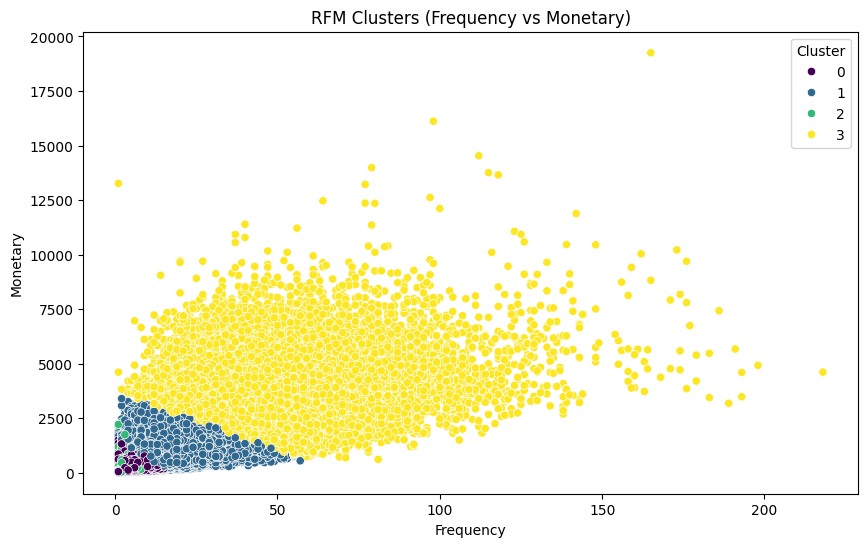

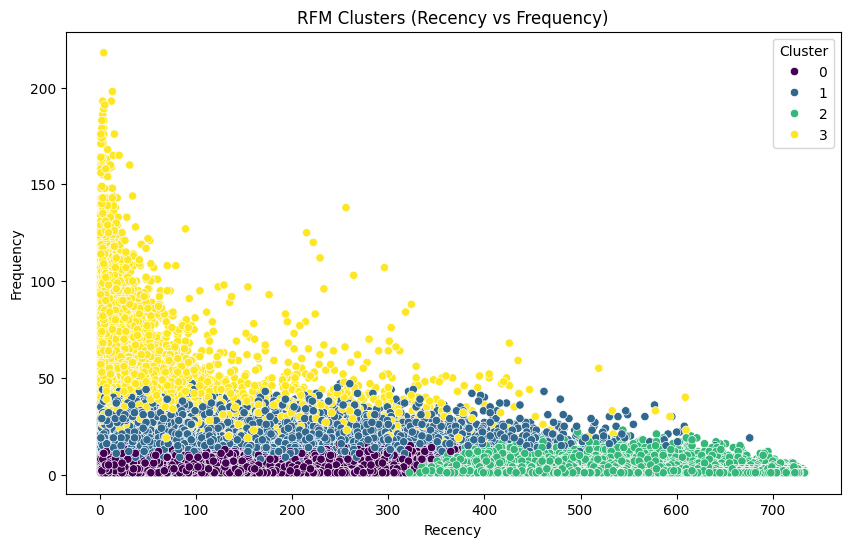

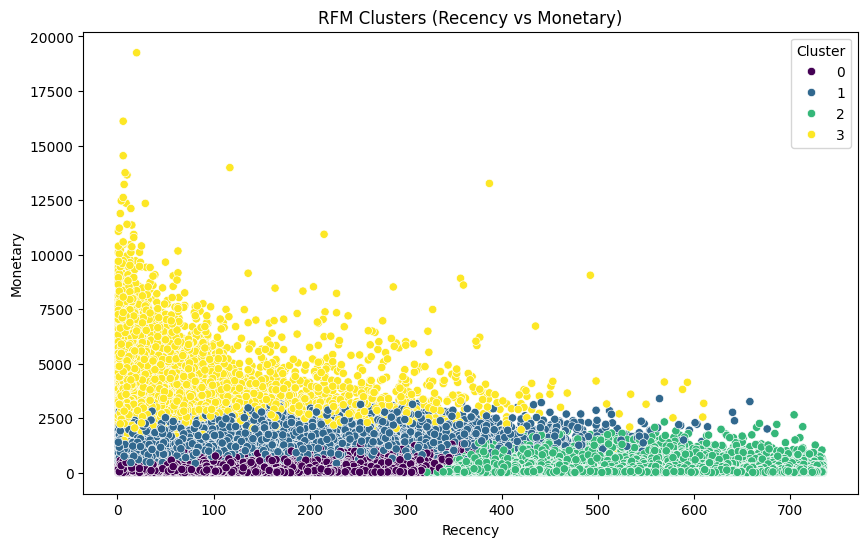

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 가장 영향력이 큰 두 축(예: Frequency, Monetary)으로 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('RFM Clusters (Frequency vs Monetary)')
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='viridis')
plt.title('RFM Clusters (Recency vs Frequency)')
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('RFM Clusters (Recency vs Monetary)')
plt.show()

- ANOVA 분석 통계성 유의미 확인 + tukey사후검정 실행

In [8]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. ANOVA 분석 (Monetary: 총 구매금액 기준)군집간에 평균차이가 있는가
f_val, p_val = stats.f_oneway(rfm[rfm['Cluster']==0]['Monetary'],
                              rfm[rfm['Cluster']==1]['Monetary'],
                              rfm[rfm['Cluster']==2]['Monetary'],
                              rfm[rfm['Cluster']==3]['Monetary'])

print(f"ANOVA 결과: F={f_val:.2f}, p-value={p_val:.4f}")

# 2. 사후 검정 (Tukey HSD)
# 어떤 군집끼리 구체적으로 차이가 나는지 확인
tukey = pairwise_tukeyhsd(endog=rfm['Monetary'],     # 데이터
                          groups=rfm['Cluster'],      # 그룹
                          alpha=0.05)                # 유의수준
print(tukey)

ANOVA 결과: F=1367160.88, p-value=0.0000
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
     0      1  818.1013   0.0  816.0621  820.1405   True
     0      2 -102.9992   0.0  -104.616 -101.3824   True
     0      3 2988.2088   0.0 2983.7274 2992.6901   True
     1      2 -921.1004   0.0 -923.3062 -918.8947   True
     1      3 2170.1075   0.0 2165.3816 2174.8334   True
     2      3  3091.208   0.0 3086.6484 3095.7675   True
--------------------------------------------------------


Pre-Corona 실제 일수: 467일
Post-Corona 실제 일수: 265일
period
Post-Corona    0.013495
Pre-Corona     0.011298
Name: daily_freq, dtype: float64
sales_channel_id         1         2
period                              
Post-Corona       0.010028  0.010848
Pre-Corona        0.008697  0.008481


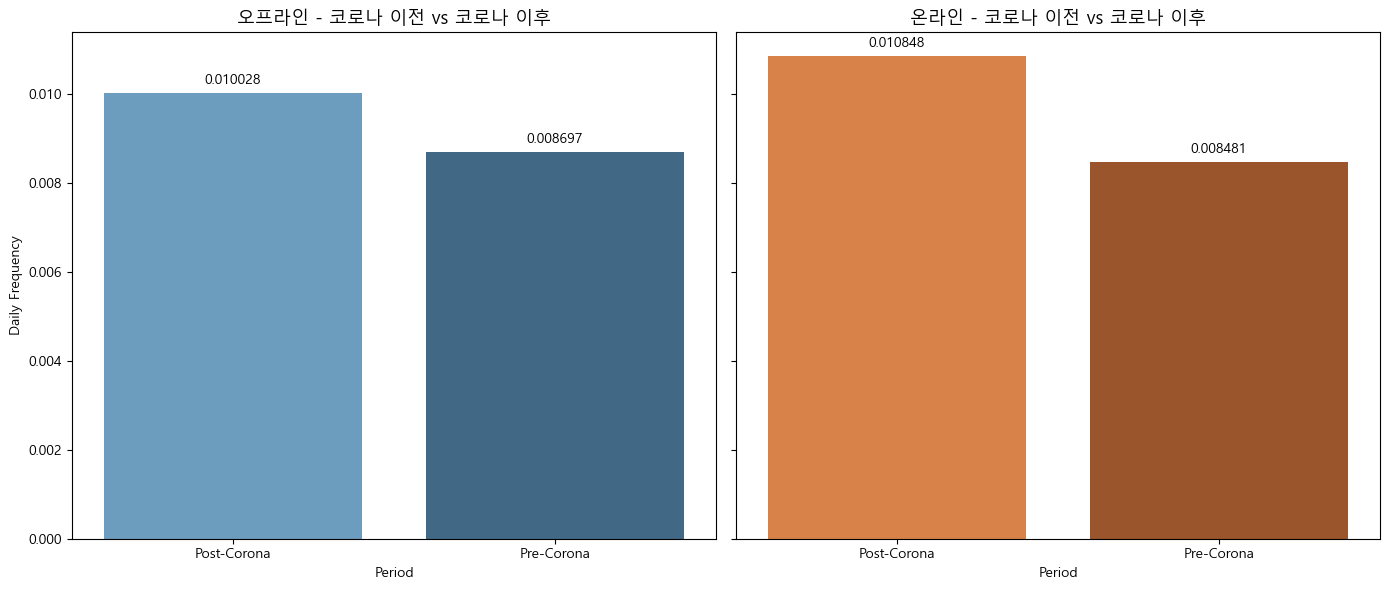

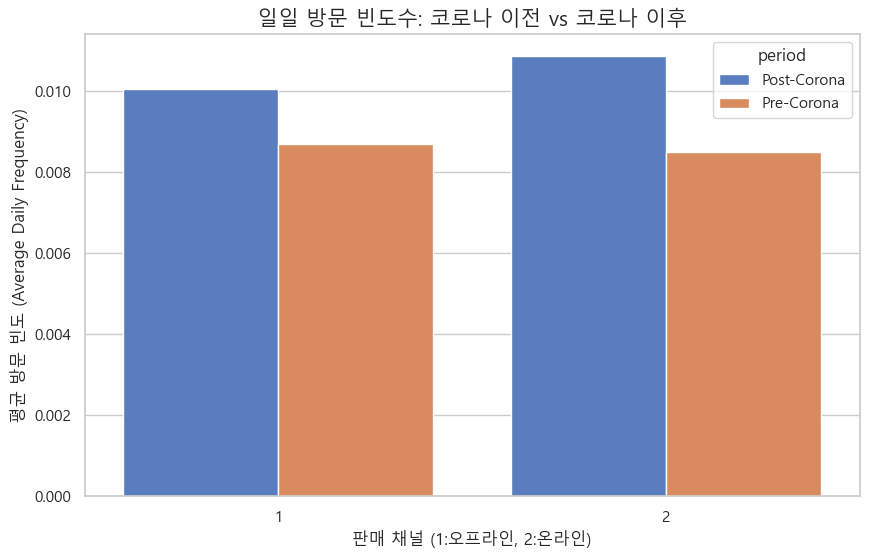

In [9]:
import pandas as pd

# 1. 날짜 데이터 형식 변환 (이미 되어있다면 생략 가능)
# final['t_dat'] = pd.to_datetime(final['t_dat'])

# 2. 코로나 전(2018~2019)과 후(2020)를 구분하는 파생변수 생성
df['period'] = df['t_dat'].dt.year.apply(lambda x: 'Pre-Corona' if x < 2020 else 'Post-Corona')

# 3. 기간별 + 고객별 방문 빈도(Frequency) 계산
# 고객이 두 기간 모두 존재할 수 있으므로 두 기준으로 그룹화합니다.
rfm_comparison = df.groupby(['period', 'customer_id'])['t_dat'].nunique().reset_index()

# 컬럼명 변경 (t_dat -> frequency)
rfm_comparison.rename(columns={'t_dat': 'frequency'}, inplace=True)
# 기간별 평균 방문 빈도 계산
analysis_result = rfm_comparison.groupby('period')['frequency'].mean()
analysis_result
# 1. 각 기간의 실제 일수(Duration) 계산
# Pre-Corona: 2018-09-20 ~ 2019-12-31
# Post-Corona: 2020-01-01 ~ 2020-09-22

pre_days = (pd.to_datetime('2019-12-31') - pd.to_datetime('2018-09-20')).days
post_days = (pd.to_datetime('2020-09-22') - pd.to_datetime('2020-01-01')).days

print(f"Pre-Corona 실제 일수: {pre_days}일")
print(f"Post-Corona 실제 일수: {post_days}일")

# 2. 일평균 방문 빈도 계산 함수
# daily_freq 계산함수 해당 기간의 총 구매 횟수 / 해당 기간의 총 일수
def get_daily_freq(row):
    if row['period'] == 'Pre-Corona':
        return row['frequency'] / pre_days
    else:
        return row['frequency'] / post_days

rfm_comparison['daily_freq'] = rfm_comparison.apply(get_daily_freq, axis=1)

# 3. 결과 비교
final_analysis = rfm_comparison.groupby('period')['daily_freq'].mean()
print(final_analysis)
# 해석:코로나 이후(Post)의 수치가 코로나 이전(Pre)보다 약 18.9% 상승했습니다.
# 코로나19 발생 이후, 고객들이 서비스를 이용하는 주기가 더 짧아졌습니다. (더 자주 들어와서 구매함)
# 1. 기간별 + 채널별 + 고객별 방문 빈도(Frequency) 계산
# nunique()를 사용하여 고객별/채널별 '방문 일수'를 구합니다.
channel_comparison = df.groupby(['period', 'sales_channel_id', 'customer_id'])['t_dat'].nunique().reset_index()
channel_comparison.rename(columns={'t_dat': 'frequency'}, inplace=True)

# 2. 일평균 방문 빈도 보정 (이미 계산된 pre_days, post_days 활용)
def get_daily_freq_channel(row):
    if row['period'] == 'Pre-Corona':
        return row['frequency'] / pre_days
    else:
        return row['frequency'] / post_days

channel_comparison['daily_freq'] = channel_comparison.apply(get_daily_freq_channel, axis=1)

channel_analysis = channel_comparison.groupby(['period', 'sales_channel_id'])['daily_freq'].mean().unstack()
print(channel_analysis)
# 3. 결과 비교: 기간별, 채널별 평균 일일 방문 빈도(1: 오프라인, 2: 온라인)
# 오프라인 방문빈도 15.3%증가
# 온라인 방문빈도 27%증가
# 온라인 채널의 압도적 성장: 오프라인 방문 빈도도 15.3% 증가하며 선방했지만,
# 온라인은 27.1%라는 폭발적인 성장을 기록했습니다.
# 주객전도 현상: 코로나 이전에는 오프라인(0.0087)이 온라인(0.0086)보다 미세하게 높았으나, 코로나 이후에는 온라인이 오프라인을 추월했습니다.
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows의 맑은 고딕 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 이후에 그래프 그리는 코드 실행
# 1. 데이터 준비 (기존 channel_analysis 활용)
plot_data = channel_analysis.stack().reset_index()
plot_data.columns = ['period', 'sales_channel_id', 'daily_freq']

# 2. 그래프 영역 생성 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True) # y축 범위를 통일하여 비교를 쉽게 함

# 3. 오프라인 데이터 시각화 (sales_channel_id == 1)
offline_data = plot_data[plot_data['sales_channel_id'] == 1]
sns.barplot(ax=axes[0], data=offline_data, x='period', y='daily_freq', palette='Blues_d')
axes[0].set_title('오프라인 - 코로나 이전 vs 코로나 이후', fontsize=13)
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Daily Frequency')

# 4. 온라인 데이터 시각화 (sales_channel_id == 2)
online_data = plot_data[plot_data['sales_channel_id'] == 2]
sns.barplot(ax=axes[1], data=online_data, x='period', y='daily_freq', palette='Oranges_d')
axes[1].set_title('온라인 - 코로나 이전 vs 코로나 이후', fontsize=13)
axes[1].set_xlabel('Period')
axes[1].set_ylabel('') # 왼쪽과 y축을 공유하므로 생략 가능

# 각 막대 위에 수치 표시 함수
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.6f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

add_labels(axes[0])
add_labels(axes[1])

plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (가장 확실한 방법)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 데이터 재구조화 및 그래프 그리기 (이미지의 코드와 동일)
plot_data = channel_analysis.stack().reset_index()
plot_data.columns = ['period', 'sales_channel_id', 'daily_freq']

sns.set_theme(style="whitegrid", font='Malgun Gothic') # 테마 설정 시 폰트 재지정
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=plot_data, x='sales_channel_id', y='daily_freq', hue='period', palette='muted')

# 3. 한글 제목 설정
plt.title('일일 방문 빈도수: 코로나 이전 vs 코로나 이후', fontsize=15)
plt.xlabel('판매 채널 (1:오프라인, 2:온라인)', fontsize=12)
plt.ylabel('평균 방문 빈도 (Average Daily Frequency)', fontsize=12)

plt.show()

In [10]:
# 군집별 매출 비중 계산 
# 소수의 핵심 고객이 전체 매출을 견인하고 있는가?
#(해당 군집 고객수 ÷ 전체 고객수 합계) × 100
#(해당 군집 매출액 ÷ 전체 매출액 합계) × 100
impact = rfm.groupby('Cluster').agg({
    'customer_id': 'count',
    'Monetary': 'sum'
}).rename(columns={'customer_id': '고객수', 'Monetary': '총매출'})

impact['고객비중(%)'] = (impact['고객수'] / impact['고객수'].sum()) * 100
impact['매출비중(%)'] = (impact['총매출'] / impact['총매출'].sum()) * 100

print(impact.sort_values('매출비중(%)', ascending=False))

            고객수          총매출    고객비중(%)    매출비중(%)
Cluster                                           
1        210709  214723712.0  15.482847  42.146862
0        708223  142318896.0  52.040055  27.934944
3         35303  112586944.0   2.594056  22.099033
2        406684   39835888.0  29.883042   7.819153


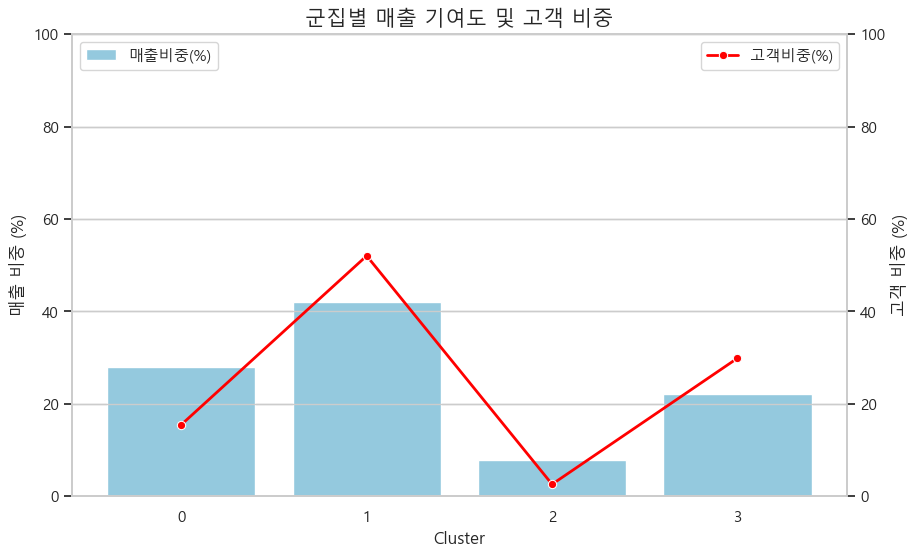

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (환경에 따라 'AppleGothic' 또는 'Malgun Gothic' 사용)
plt.rc('font', family='Malgun Gothic') 

# 데이터 정렬 (매출 비중 높은 순)
viz_data = impact.sort_values('매출비중(%)', ascending=False).reset_index()

# 시각화 시작
fig, ax1 = plt.subplots(figsize=(10, 6))

# 1. 매출 비중 (막대 그래프)
sns.barplot(data=viz_data, x='Cluster', y='매출비중(%)', ax=ax1, color='skyblue', label='매출비중(%)')
ax1.set_ylabel('매출 비중 (%)')
ax1.set_ylim(0, 100)

# 2. 고객 비중 (꺾은선 그래프 - 이중 축 사용)
ax2 = ax1.twinx()
sns.lineplot(data=viz_data, x=range(len(viz_data)), y='고객비중(%)', ax=ax2, 
             color='red', marker='o', linewidth=2, label='고객비중(%)')
ax2.set_ylabel('고객 비중 (%)')
ax2.set_ylim(0, 100)

# 제목 및 레이아웃 정리
plt.title('군집별 매출 기여도 및 고객 비중', fontsize=15)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

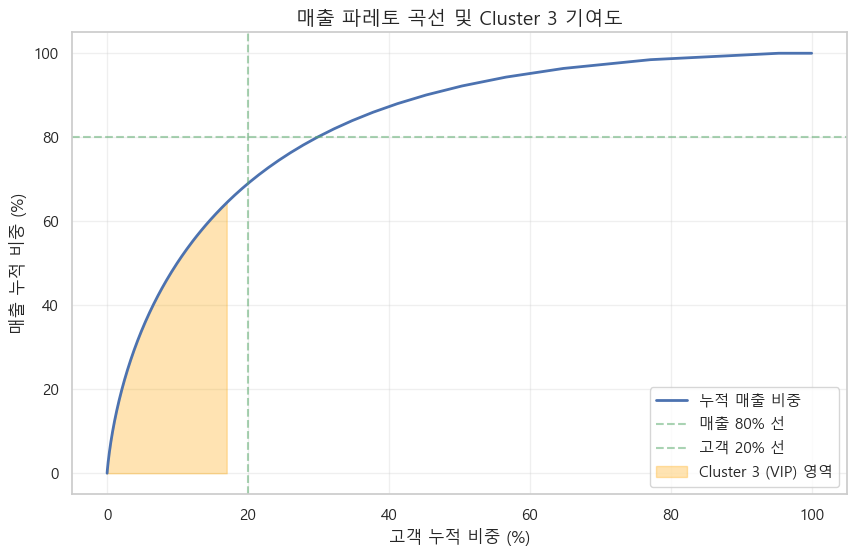

Cluster 3은 전체 고객의 약 17.0%이며, 전체 매출의 약 64.4%를 차지합니다.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비: 매출순 정렬 및 누적 합계 계산
pareto_df = rfm.sort_values('Monetary', ascending=False).reset_index()
pareto_df['cum_customer_pct'] = (pareto_df.index + 1) / len(pareto_df) * 100
pareto_df['cum_monetary_pct'] = pareto_df['Monetary'].cumsum() / pareto_df['Monetary'].sum() * 100

# 2. Cluster 3의 경계 지점 찾기 (Cluster 3이 매출 최상위라고 가정 시)
c3_max_customer_pct = pareto_df[pareto_df['Cluster'] == 3]['cum_customer_pct'].max()
c3_max_monetary_pct = pareto_df[pareto_df['Cluster'] == 3]['cum_monetary_pct'].max()

# 3. 시각화
plt.figure(figsize=(10, 6))
plt.plot(pareto_df['cum_customer_pct'], pareto_df['cum_monetary_pct'], label='누적 매출 비중', color='b', linewidth=2)

# 파레토 기준선 (80/20 법칙 가이드라인)
plt.axhline(80, color='g', linestyle='--', alpha=0.5, label='매출 80% 선')
plt.axvline(20, color='g', linestyle='--', alpha=0.5, label='고객 20% 선')

# Cluster 3 영역 강조 (VIP 구간)
plt.fill_between(pareto_df['cum_customer_pct'], 0, pareto_df['cum_monetary_pct'], 
                 where=(pareto_df['cum_customer_pct'] <= c3_max_customer_pct), 
                 color='orange', alpha=0.3, label='Cluster 3 (VIP) 영역')

plt.title('매출 파레토 곡선 및 Cluster 3 기여도', fontsize=14)
plt.xlabel('고객 누적 비중 (%)')
plt.ylabel('매출 누적 비중 (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Cluster 3은 전체 고객의 약 {c3_max_customer_pct:.1f}%이며, 전체 매출의 약 {c3_max_monetary_pct:.1f}%를 차지합니다.")

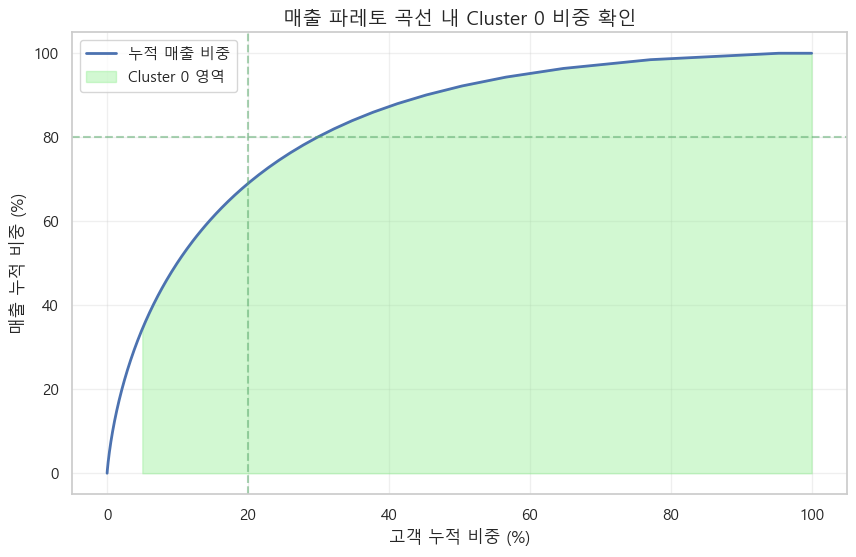

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비: 매출순 정렬 및 누적 비중 계산
pareto_df = rfm.sort_values('Monetary', ascending=False).reset_index()
pareto_df['cum_customer_pct'] = (pareto_df.index + 1) / len(pareto_df) * 100
pareto_df['cum_monetary_pct'] = pareto_df['Monetary'].cumsum() / pareto_df['Monetary'].sum() * 100

# 2. Cluster 0의 영역 계산
# Cluster 0에 속한 데이터들의 누적 고객 비중 범위를 찾습니다.
c0_indices = pareto_df[pareto_df['Cluster'] == 0].index
c0_min_pct = (min(c0_indices) / len(pareto_df)) * 100
c0_max_pct = (max(c0_indices) / len(pareto_df)) * 100

# 3. 시각화
plt.figure(figsize=(10, 6))
plt.plot(pareto_df['cum_customer_pct'], pareto_df['cum_monetary_pct'], label='누적 매출 비중', color='b', linewidth=2)

# 파레토 기준선 (80/20 법칙)
plt.axhline(80, color='g', linestyle='--', alpha=0.5)
plt.axvline(20, color='g', linestyle='--', alpha=0.5)

# Cluster 0 영역 강조 (일반 고객 구간)
plt.fill_between(pareto_df['cum_customer_pct'], 0, pareto_df['cum_monetary_pct'], 
                 where=((pareto_df['cum_customer_pct'] >= c0_min_pct) & (pareto_df['cum_customer_pct'] <= c0_max_pct)), 
                 color='lightgreen', alpha=0.4, label='Cluster 0 영역')

plt.title('매출 파레토 곡선 내 Cluster 0 비중 확인', fontsize=14)
plt.xlabel('고객 누적 비중 (%)')
plt.ylabel('매출 누적 비중 (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 클러스터

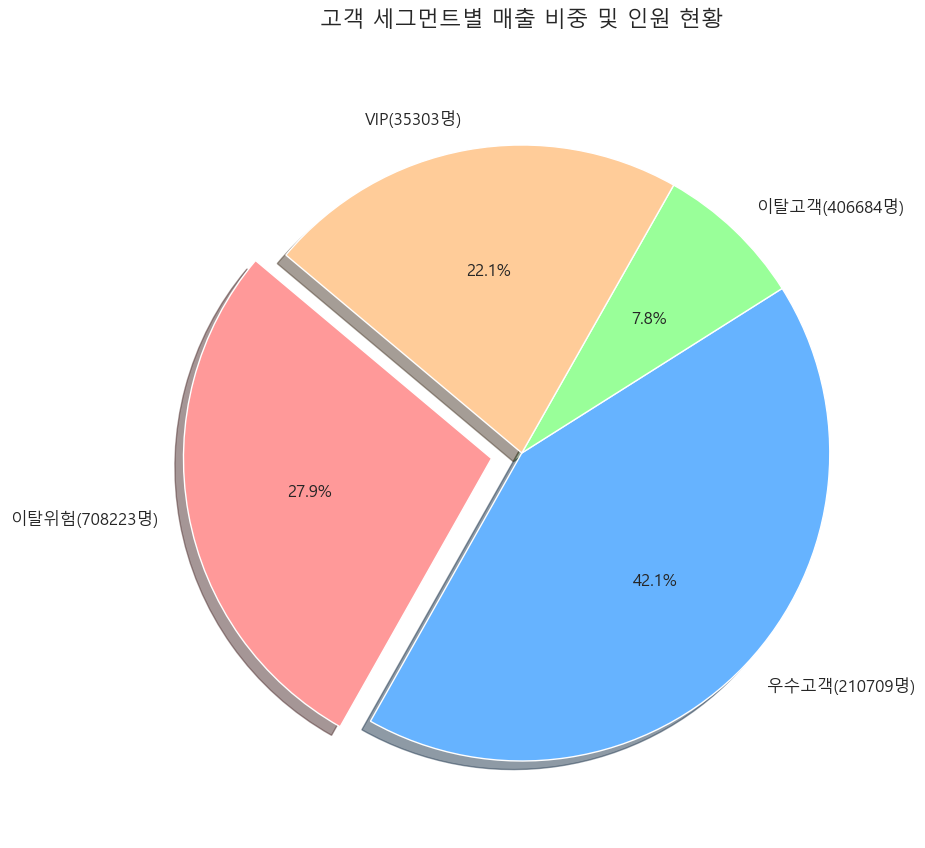

In [14]:
import matplotlib.pyplot as plt

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic' 

# 1. 클러스터 번호와 이름을 매핑하는 딕셔너리 생성
cluster_names = {
    3: 'VIP',
    1: '우수고객',
    0: '이탈위험',
    2: '이탈고객'
}

# 2. 데이터 설정 및 라벨 생성 (이름 + 고객수)
# impact['고객수'] 컬럼이 있다고 가정합니다.
labels = [f"{cluster_names[i]}({impact.loc[i, '고객수']}명)" for i in impact.index]
sizes = impact['총매출']

# 3. Cluster 0(이탈위험) 강조 설정
explode = [0.1 if i == 0 else 0 for i in impact.index] 

plt.figure(figsize=(10, 10))
plt.pie(sizes, 
        explode=explode, 
        labels=labels, 
        autopct='%1.1f%%', 
        shadow=True, 
        startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'],
        textprops={'fontsize': 12}) # 글자 크기 조절

plt.title('고객 세그먼트별 매출 비중 및 인원 현황', fontsize=16, pad=30)
plt.show()

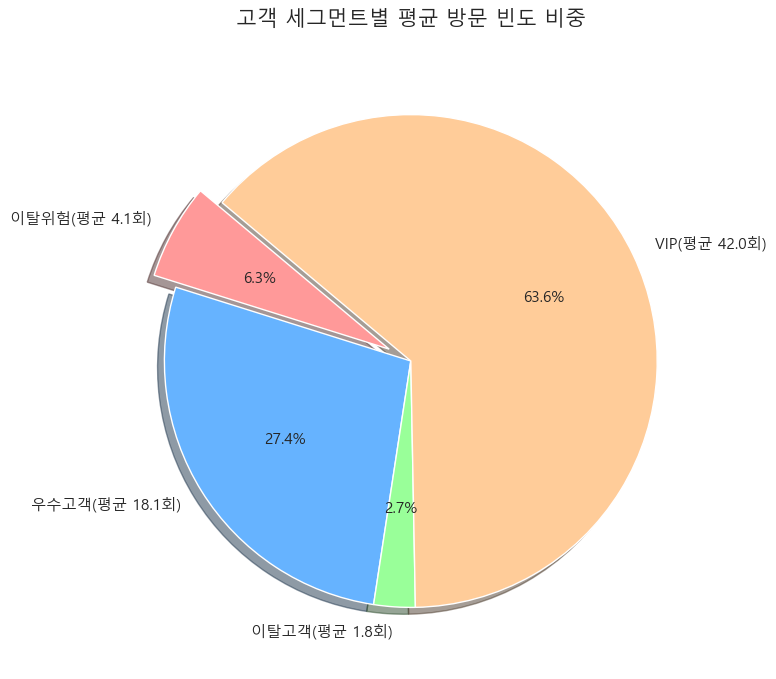

In [15]:
import matplotlib.pyplot as plt

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic' 

# 1. 클러스터별 이름 매핑 딕셔너리
cluster_names = {
    3: 'VIP',
    1: '우수고객',
    0: '이탈위험',
    2: '이탈고객'
}

# 2. 데이터 설정 (평균 방문 횟수)
freq_impact = rfm.groupby('Cluster')['Frequency'].mean()

# 3. 라벨 생성: 이름 + (평균 방문 횟수)
# 예: VIP (평균 15.2회)
labels = [f"{cluster_names[i]}(평균 {freq_impact[i]:.1f}회)" for i in freq_impact.index]
sizes = freq_impact.values

# 4. Cluster 0(이탈위험) 강조 설정
explode = [0.1 if i == 0 else 0 for i in freq_impact.index] 

plt.figure(figsize=(8, 8))
plt.pie(sizes, 
        explode=explode, 
        labels=labels, 
        autopct='%1.1f%%', 
        shadow=True, 
        startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'],
        textprops={'fontsize': 11})

plt.title('고객 세그먼트별 평균 방문 빈도 비중', fontsize=15, pad=20)
plt.show()

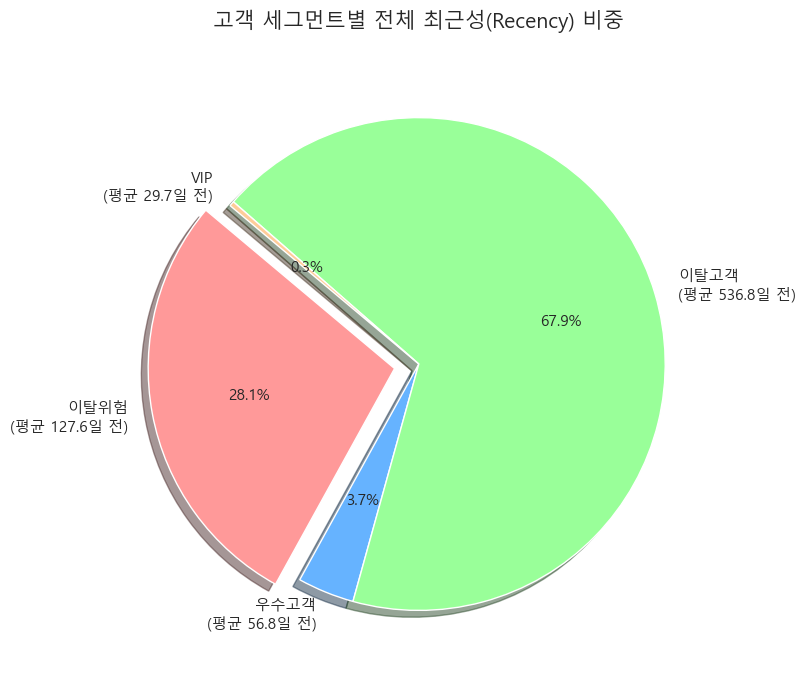

In [16]:
import matplotlib.pyplot as plt

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic' 

# 1. 클러스터별 이름 매핑 딕셔너리
cluster_names = {
    3: 'VIP',
    1: '우수고객',
    0: '이탈위험',
    2: '이탈고객'
}

# 2. 클러스터별 평균 최근성 계산
# (마지막 구매일로부터 평균 며칠이 지났는가?)
recency_mean = rfm.groupby('Cluster')['Recency'].mean()

# 3. 데이터 설정 및 라벨 생성 (이름 + 평균 경과일)
labels = [f"{cluster_names[i]}\n(평균 {recency_mean[i]:.1f}일 전)" for i in recency_mean.index]
sizes = rfm.groupby('Cluster')['Recency'].sum() # 파이 조각 크기는 전체 합계 비중 유지

# 4. Cluster 0(이탈위험) 강조 설정
explode = [0.1 if i == 0 else 0 for i in recency_mean.index] 

plt.figure(figsize=(8, 8))
plt.pie(sizes, 
        explode=explode, 
        labels=labels, 
        autopct='%1.1f%%', 
        shadow=True, 
        startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'],
        textprops={'fontsize': 11})

plt.title('고객 세그먼트별 전체 최근성(Recency) 비중', fontsize=15, pad=20)
plt.show()
# 비중이 작게나오면 마지막으로 방문한지 얼마안지남
# 비중이 크게나오면 마지막으로 방문한지 오래지남

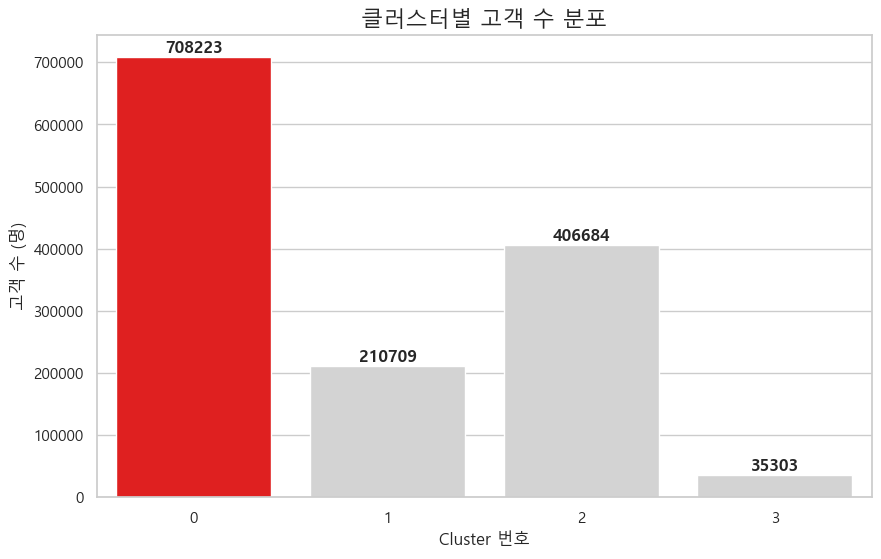

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 클러스터별 고객 수 계산 및 정렬
cluster_counts = rfm['Cluster'].value_counts().sort_index()

# 2. 시각화 설정
plt.figure(figsize=(10, 6))
colors = ['red' if i == 0 else 'lightgrey' for i in cluster_counts.index] # Cluster 0만 빨간색으로 강조

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=colors)

# 차트 꾸미기
plt.title('클러스터별 고객 수 분포', fontsize=16)
plt.xlabel('Cluster 번호', fontsize=12)
plt.ylabel('고객 수 (명)', fontsize=12)

# 막대 위에 숫자 표시 (데이터 레이블)
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')

plt.show()

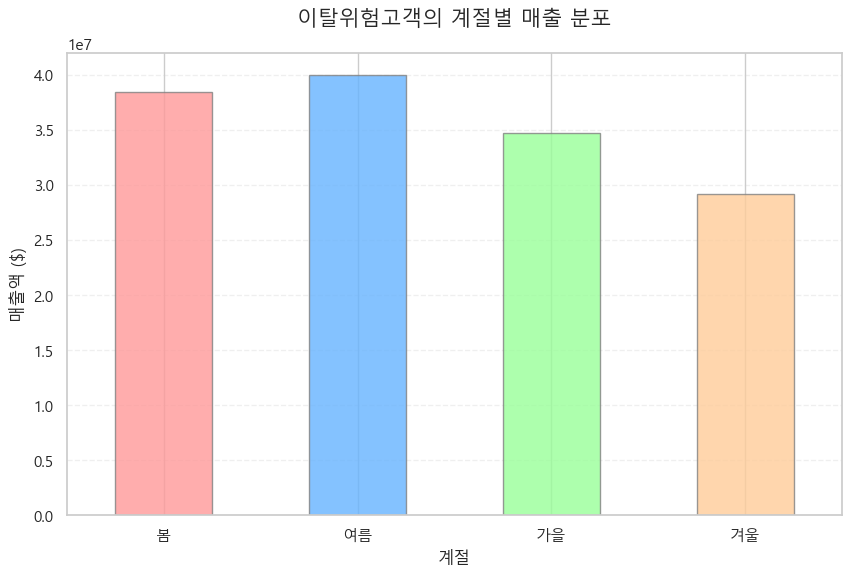

In [18]:
c0_users = rfm[rfm['Cluster'] == 0]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c0_data = df[df['customer_id'].isin(c0_users)]
# 1. 월 데이터 추출 및 계절 매핑
c0_data['month'] = c0_data['t_dat'].dt.month

def get_season(month):
    if month in [3, 4, 5]: return '봄'
    elif month in [6, 7, 8]: return '여름'
    elif month in [9, 10, 11]: return '가을'
    else: return '겨울'

c0_data['season'] = c0_data['month'].apply(get_season)

# 2. 계절별 매출 합계 계산
season_sales = c0_data.groupby('season')['price'].sum()
import matplotlib.pyplot as plt

# 1. 사용할 색상 리스트 정의
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

# 2. 시각화
plt.figure(figsize=(10, 6))

# 데이터를 봄-여름-가을-겨울 순서로 재정렬하고 color 인자에 리스트 전달
season_sales.reindex(['봄', '여름', '가을', '겨울']).plot(
    kind='bar', 
    color=colors, 
    edgecolor='gray', # 막대 테두리를 살짝 주면 더 깔끔합니다
    alpha=0.8 # 색감을 부드럽게 만들기 위한 투명도 조절
)

plt.title('이탈위험고객의 계절별 매출 분포', fontsize=15, pad=20)
plt.ylabel('매출액 ($)', fontsize=12)
plt.xlabel('계절', fontsize=12)
plt.xticks(rotation=0) # 글자를 가로로 정렬

# 그리드를 추가하면 수치 확인이 더 편합니다 (선택 사항)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

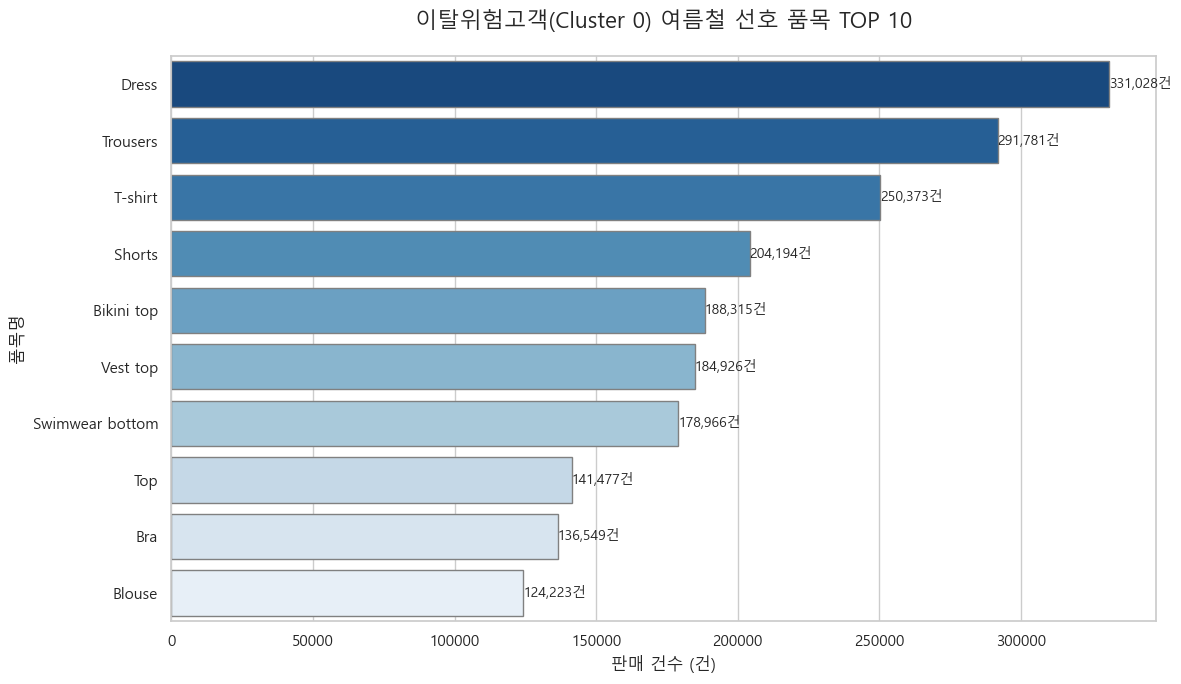

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'

# 1. 여름 데이터에서 상위 10개 품목 추출
summer_top10_data = c0_data[c0_data['season'] == '여름']['product_type_name'].value_counts().head(10)

# [중요] 카테고리 타입의 흔적을 지우기 위해 문자열로 변환하고 다시 정렬
top10_df = summer_top10_data.reset_index()
top10_df.columns = ['product_type_name', 'count']
top10_df['product_type_name'] = top10_df['product_type_name'].astype(str) # 문자열 변환

# 2. 시각화
plt.figure(figsize=(12, 7))

# 데이터를 명확하게 전달하여 시각화
sns.barplot(
    data=top10_df,
    x='count', 
    y='product_type_name', 
    palette='Blues_r', 
    edgecolor='gray'
)

# 3. 그래프 디테일 설정
plt.title('이탈위험고객(Cluster 0) 여름철 선호 품목 TOP 10', fontsize=16, pad=20)
plt.xlabel('판매 건수 (건)', fontsize=12)
plt.ylabel('품목명', fontsize=12)

# 막대 끝에 숫자 표시
for i, v in enumerate(top10_df['count']):
    plt.text(v + 3, i, f'{int(v):,}건', va='center', fontsize=10)

plt.tight_layout()
plt.show()

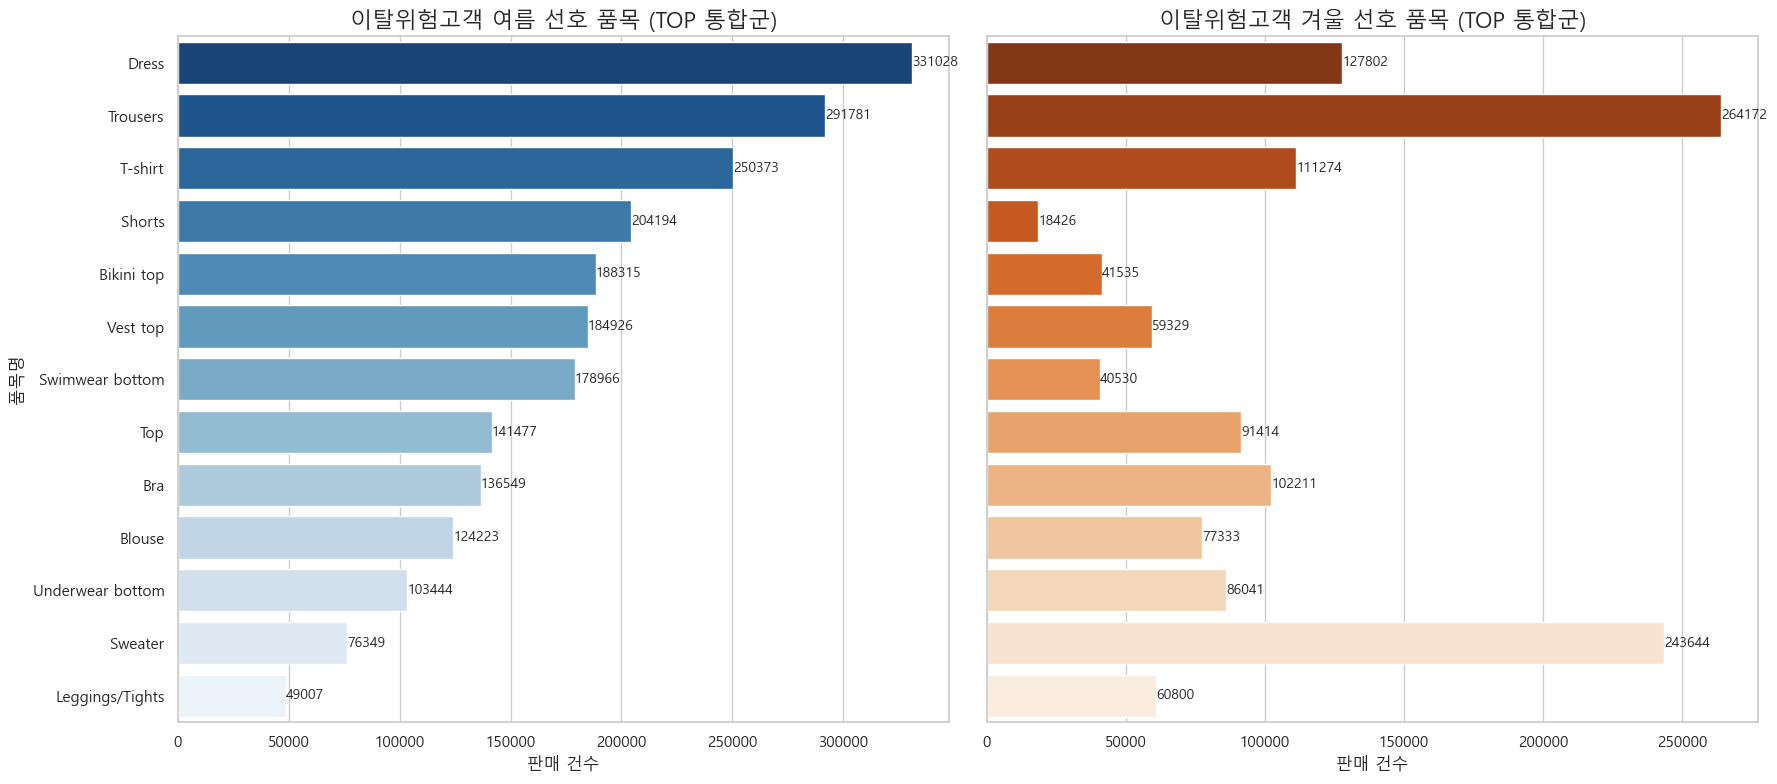

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 여름과 겨울의 TOP 10 품목 리스트를 추출하여 합치기 (통합 기준 생성)
summer_top10 = c0_data[c0_data['season'] == '여름']['product_type_name'].value_counts().head(10)
winter_top10 = c0_data[c0_data['season'] == '겨울']['product_type_name'].value_counts().head(10)

# 두 계절의 TOP 10에 포함된 모든 품목을 중복 없이 합침
combined_top_items = list(set(summer_top10.index) | set(winter_top10.index))

# 2. 통합 리스트를 기준으로 판매 건수 다시 집계
summer_data = c0_data[c0_data['season'] == '여름']['product_type_name'].value_counts().reindex(combined_top_items, fill_value=0).sort_values(ascending=False)
# 겨울 데이터도 동일한 품목 순서로 맞춤 (비교를 위해 여름 순서 기준 혹은 통합 순서 기준)
winter_data = c0_data[c0_data['season'] == '겨울']['product_type_name'].value_counts().reindex(summer_data.index, fill_value=0)

# 3. 시각화
fig, ax = plt.subplots(1, 2, figsize=(18, 8), sharey=True) # sharey=True로 Y축 품목명을 통일

# 여름 차트
sns.barplot(x=summer_data.values, y=summer_data.index, ax=ax[0], palette='Blues_r')
ax[0].set_title('이탈위험고객 여름 선호 품목 (TOP 통합군)', fontsize=16)
ax[0].set_xlabel('판매 건수', fontsize=12)
ax[0].set_ylabel('품목명', fontsize=12)

# 겨울 차트
sns.barplot(x=winter_data.values, y=winter_data.index, ax=ax[1], palette='Oranges_r')
ax[1].set_title('이탈위험고객 겨울 선호 품목 (TOP 통합군)', fontsize=16)
ax[1].set_xlabel('판매 건수', fontsize=12)
ax[1].set_ylabel('') # 왼쪽 차트와 공유하므로 생략

# 데이터 레이블 추가 (막대 끝에 숫자 표시)
for i, v in enumerate(summer_data.values):
    ax[0].text(v + 3, i, f'{int(v)}', va='center', fontsize=10)
for i, v in enumerate(winter_data.values):
    ax[1].text(v + 3, i, f'{int(v)}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

여름에 함께 구매된 품목 TOP 10:
product_type_name
Trousers           110496
Shorts              93310
T-shirt             89193
Vest top            86938
Blouse              81078
Top                 72032
Skirt               64101
Bikini top          46659
Swimwear bottom     44462
Bra                 33108
Name: count, dtype: int64


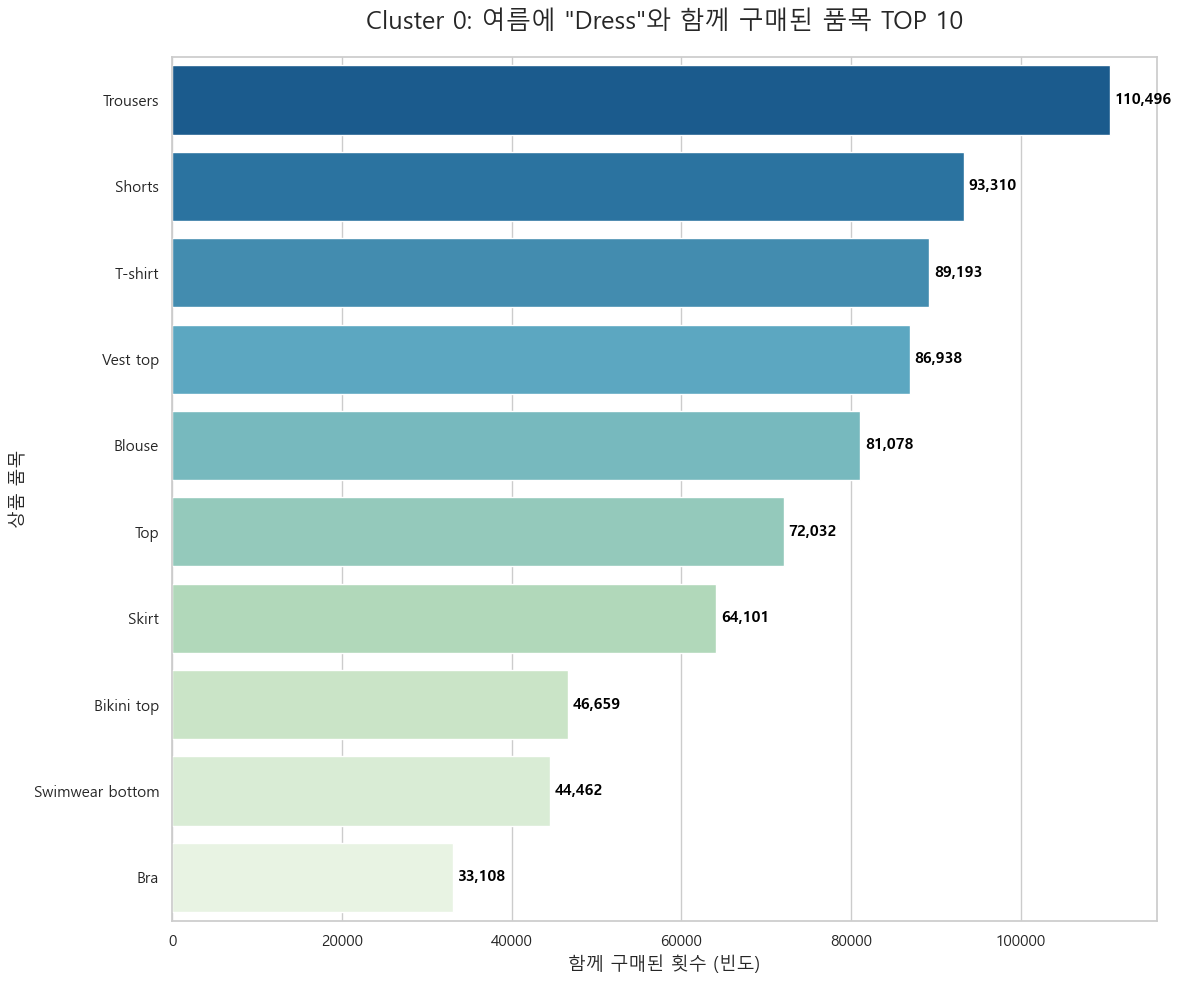

In [21]:
#cluster 0고객들이 같은 날 함께 장바구니에 담았던 다른품목 top5
def get_season_association(data, season_name, target_product):
    # 1. 해당 계절 데이터만 추출
    season_df = data[data['season'] == season_name]
    
    # 2. 타겟 상품을 구매한 영수증(고객+날짜 조합) 찾기
    # 여기서는 동일한 날짜(t_dat)에 동일한 고객(customer_id)이 구매한 것을 하나의 트랜잭션으로 간주
    target_tx = season_df[season_df['product_type_name'] == target_product][['customer_id', 't_dat']]
    
    # 3. 해당 영수증에 포함된 다른 상품들 추출
    all_related_items = season_df.merge(target_tx, on=['customer_id', 't_dat'])
    
    # 4. 타겟 상품 본인을 제외하고 빈도 계산
    association_result = all_related_items[all_related_items['product_type_name'] != target_product]
    return association_result['product_type_name'].value_counts().head(10)

# 실행 예시: "여름"OO을 산 고객이 함께 산 품목은?
print("여름에 함께 구매된 품목 TOP 10:")
print(get_season_association(c0_data, '여름', 'Dress'))
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 이전 그래프 잔상 완전히 제거
plt.close('all') 
# 10개를 보여줘야 하므로 높이(height)를 10으로 조금 더 키웠습니다.
plt.figure(figsize=(12, 10))

# 2. 데이터 추출 (TOP 10으로 변경)
top10_data = get_season_association(c0_data, '여름', 'Dress').head(10)

# 3. 시각화
# 10개 품목을 명확하게 구분하기 위해 'GnBu_r' 팔레트를 적용합니다.
ax = sns.barplot(x=top10_data.values, 
                 y=top10_data.index, 
                 palette='GnBu_r',
                 order=top10_data.index) 

# 4. 그래프 꾸미기
plt.title('Cluster 0: 여름에 "Dress"와 함께 구매된 품목 TOP 10', fontsize=18, pad=20)
plt.xlabel('함께 구매된 횟수 (빈도)', fontsize=13)
plt.ylabel('상품 품목', fontsize=13)

# 5. 수치 표시
# 막대 우측에 빈도수 콤마(,) 포함하여 표시
for i, v in enumerate(top10_data.values):
    ax.text(v + (max(top10_data.values) * 0.005), i, f'{int(v):,}', 
            color='black', va='center', fontweight='bold', fontsize=11)

# 품목 이름이 잘리지 않도록 여백 조정
plt.tight_layout()
plt.show()

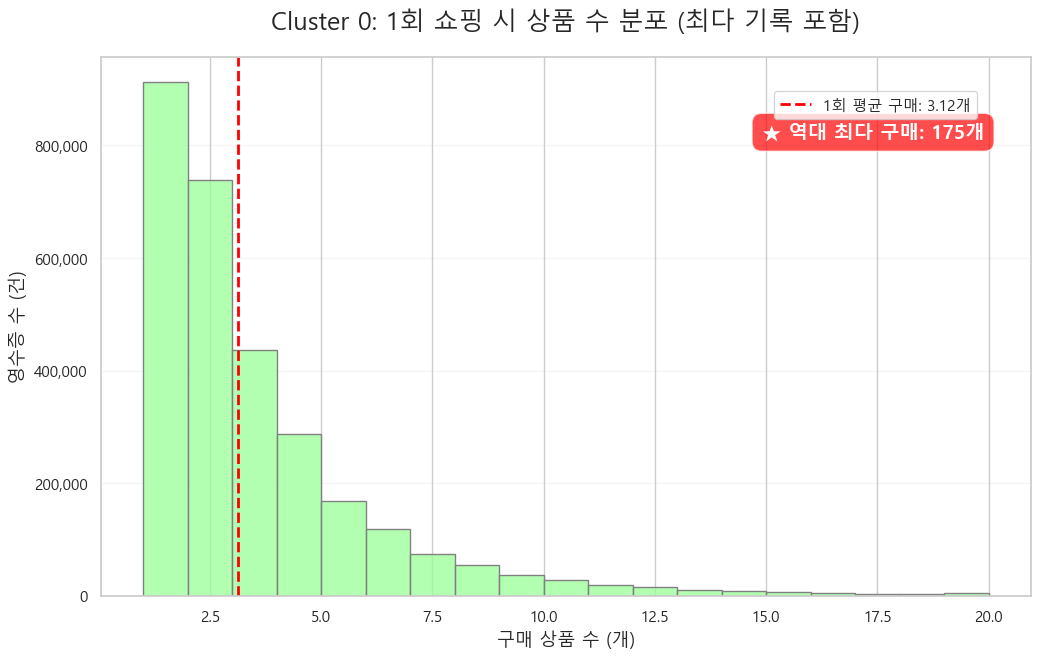

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
basket_size = c0_data.groupby(['customer_id', 't_dat']).size().reset_index(name='item_count')

# 2. 전체 평균 계산
avg_items = basket_size['item_count'].mean()#cluster0고객들의 평균 구매횟수
max_items = basket_size['item_count'].max()
# 1. 시각화 도화지 설정
plt.figure(figsize=(12, 7))

# 2. 분포 히스토그램 (대다수가 포함되는 1~20개 구간 위주)
ax = sns.histplot(basket_size['item_count'], bins=range(1, 21), kde=False, color='#99ff99', edgecolor='grey')

# 3. 주요 통계치 계산
avg_items = basket_size['item_count'].mean()
max_items = basket_size['item_count'].max() # 최다 구매 상품 수

# 4. 최다 구매 수(Max) 강조 텍스트 박스 추가
# 그래프 오른쪽 상단에 '훈장'처럼 박스를 그려줍니다.
plt.text(0.95, 0.85, f'★ 역대 최다 구매: {max_items}개', 
         transform=ax.transAxes, 
         fontsize=14, fontweight='bold', color='white',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.7),
         ha='right')

# 5. 평균선 표시
plt.axvline(avg_items, color='red', linestyle='--', linewidth=2, label=f'1회 평균 구매: {avg_items:.2f}개')

# 6. 그래프 꾸미기
plt.title('Cluster 0: 1회 쇼핑 시 상품 수 분포 (최다 기록 포함)', fontsize=18, pad=20)
plt.xlabel('구매 상품 수 (개)', fontsize=13)
plt.ylabel('영수증 수 (건)', fontsize=13)

# Y축 지수 표기법 제거 (읽기 편하게 콤마 표시)
plt.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.grid(axis='y', alpha=0.2)
plt.show()

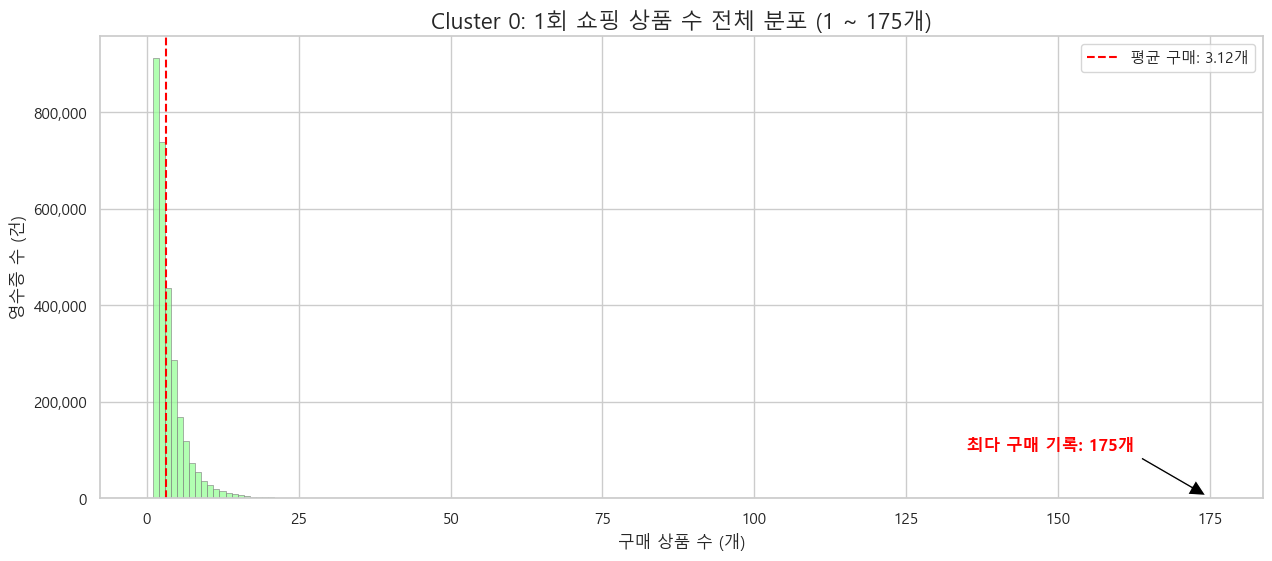

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화 준비
plt.figure(figsize=(15, 6))

# 2. X축 범위를 최다 구매 상품 수(max_items)까지 전체 설정
# bins를 넉넉히 주어 전체 범위를 커버합니다.
ax = sns.histplot(basket_size['item_count'], bins=max_items, color='#99ff99', edgecolor='grey')

# 3. 최다 구매 지점(175개)에 화살표와 텍스트 표시
plt.annotate(f'최다 구매 기록: {max_items}개', 
             xy=(max_items, 1000), # 막대 하단 위치
             xytext=(max_items - 40, 100000), # 텍스트 위치 (가독성을 위해 왼쪽 위로)
             arrowprops=dict(facecolor='black', shrink=0.05, width=2),
             fontsize=12, fontweight='bold', color='red')

# 4. 평균선 표시
plt.axvline(avg_items, color='red', linestyle='--', label=f'평균 구매: {avg_items:.2f}개')

# 5. 그래프 꾸미기
plt.title(f'Cluster 0: 1회 쇼핑 상품 수 전체 분포 (1 ~ {max_items}개)', fontsize=16)
plt.xlabel('구매 상품 수 (개)')
plt.ylabel('영수증 수 (건)')

# Y축 콤마 표시
plt.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.legend()
plt.show()

## 코호트

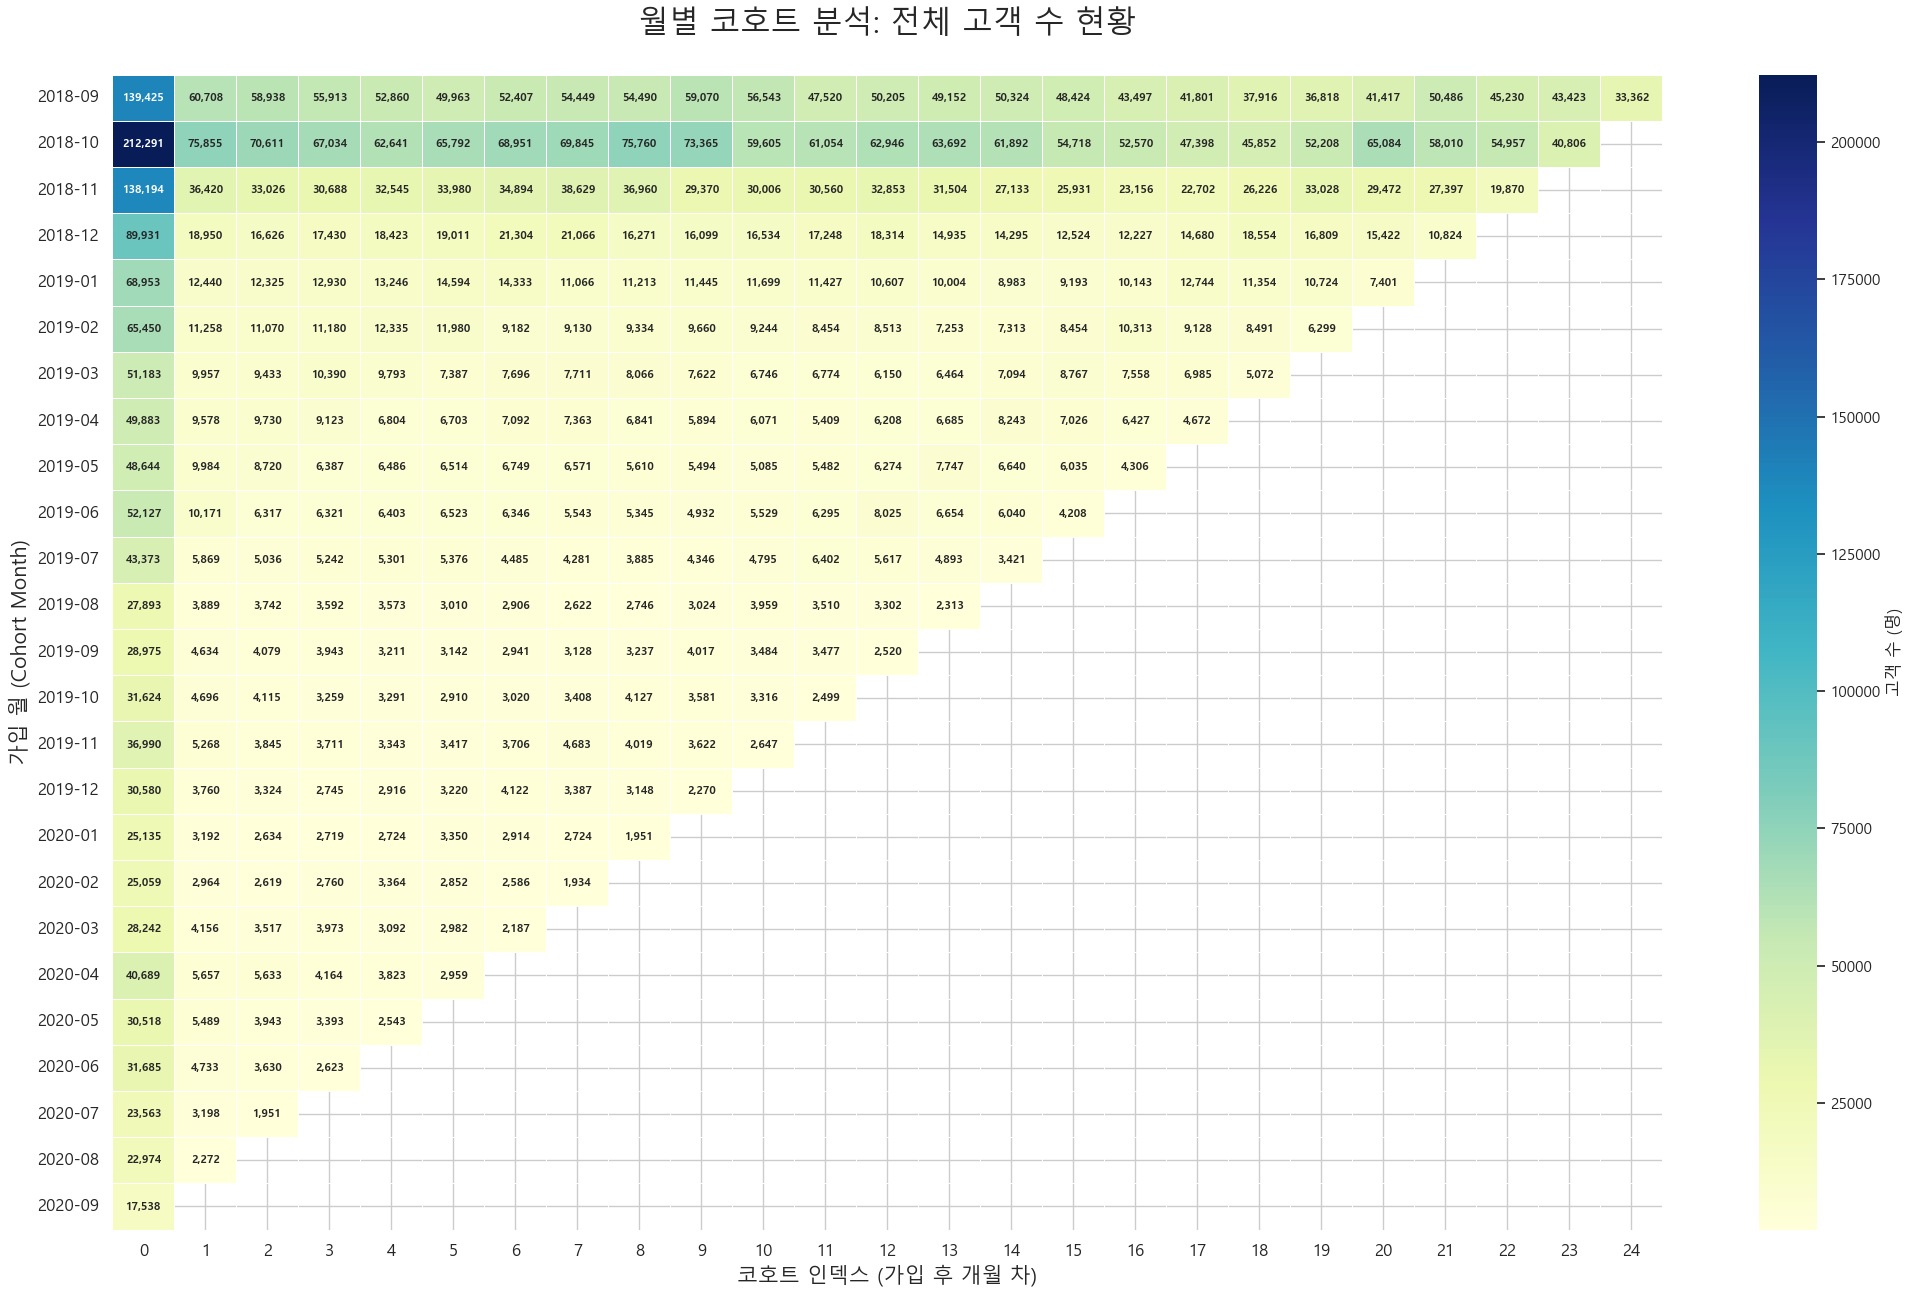

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 월 단위 변환
df['order_month'] = df['t_dat'].dt.to_period('M')

# 2. 고객별 첫 구매 월 추출
df['cohort_month'] = df.groupby('customer_id')['order_month'].transform('min')

# 3. 몇 개월째 방문인지 확인 (정수형 변환)(현재 구매 월 - 첫 구매 월)
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

# 4. 코호트 데이터 집계 (전체 고객 수)
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()

# 5. 피벗 테이블 생성
cohort_matrix = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

# 1. 이전 설정 초기화 및 캔버스 설정
plt.close('all')
# 셀이 가로로 길기 때문에 너비를 충분히 확보합니다.
plt.figure(figsize=(25, 15)) 

# 2. 히트맵 그리기
# 원본 데이터(cohort_matrix)를 그대로 사용합니다.
ax = sns.heatmap(cohort_matrix, 
                 annot=True, 
                 fmt=',.0f',       # 천 단위 콤마 추가 (예: 122,997)
                 cmap='YlGnBu', 
                 linewidths=.5,    # 셀 사이 간격 추가 (글자 겹침 완화)
                 cbar_kws={'label': '고객 수 (명)'},
                 annot_kws={"size": 8, "weight": "bold"}) # 글자 크기를 줄이고 굵게 설정

# 3. 디자인 디테일 수정
plt.title('월별 코호트 분석: 전체 고객 수 현황', fontsize=22, pad=30)
plt.xlabel('코호트 인덱스 (가입 후 개월 차)', fontsize=15)
plt.ylabel('가입 월 (Cohort Month)', fontsize=15)

# x축 라벨이 잘 보이도록 조정
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

--- 2018-10 코호트 이탈자(한 달 광탈)의 첫 상품 ---
product_type_name
Trousers           5489
Sweater            5359
T-shirt            1834
Jacket             1798
Dress              1465
Hoodie             1381
Shirt              1225
Blouse             1174
Top                 968
Leggings/Tights     898
Name: count, dtype: int64
--- 2018-10 코호트 잔류자(재방문 성공)의 첫 상품 ---
product_type_name
Sweater     34806
Trousers    28305
T-shirt      9722
Dress        9717
Blouse       9012
Jacket       6826
Top          6812
Bra          5889
Hoodie       5334
Shirt        5217
Name: count, dtype: int64


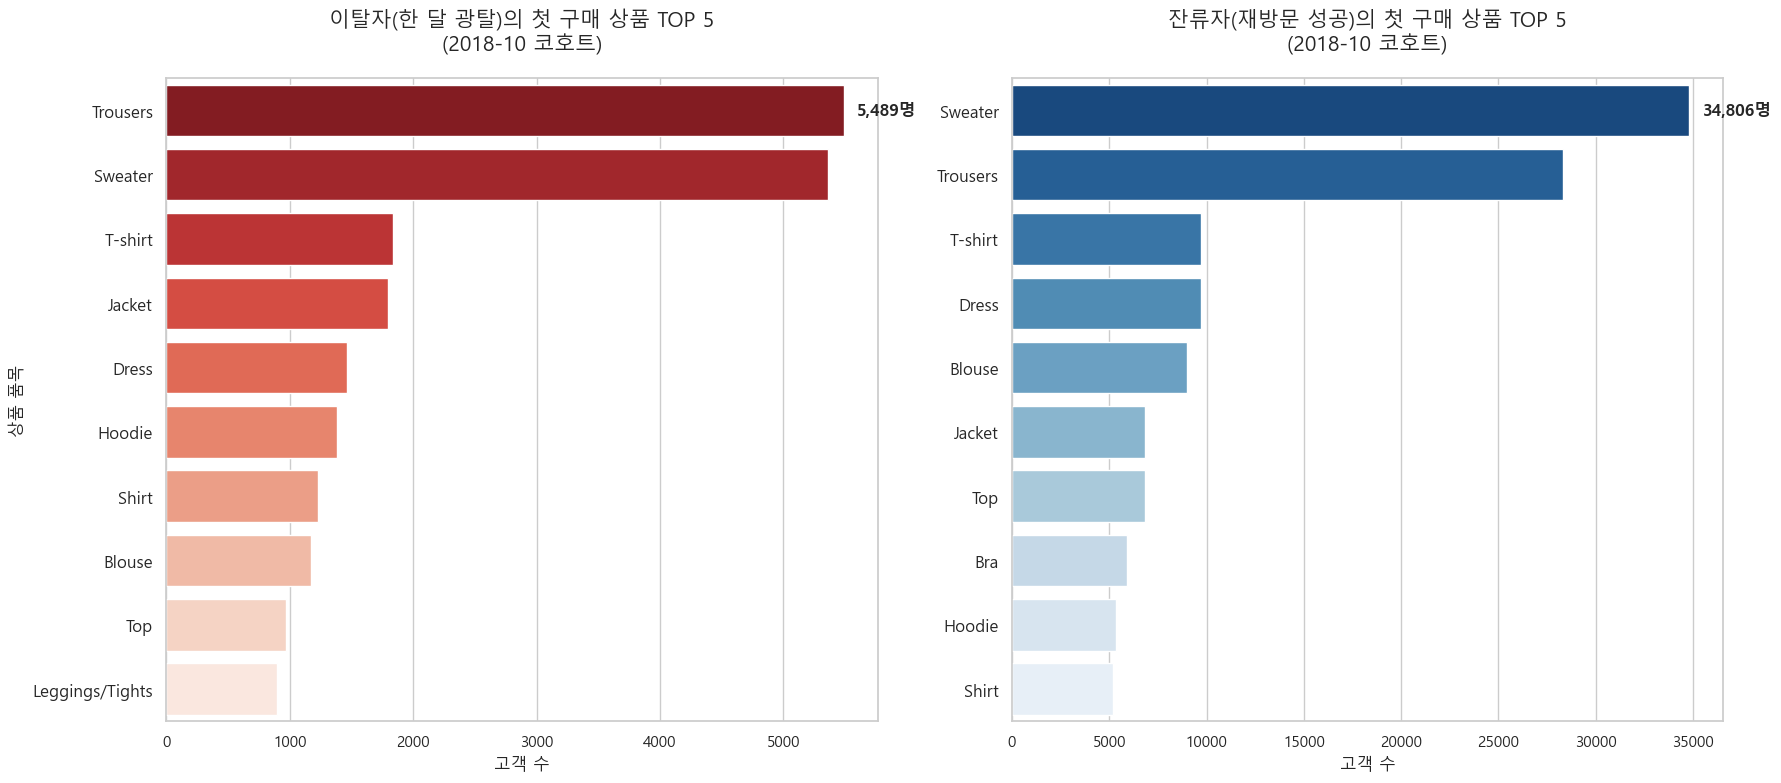

In [25]:
# 1. 아까 만든 코호트 인덱스를 활용해 '이탈 여부' 판별
# 각 고객의 최대 코호트 인덱스가 0이면 -> 한 달만 사고 다신 안 온 사람(이탈)
user_max_index = df.groupby('customer_id')['cohort_index'].max().reset_index()
user_max_index.columns = ['customer_id', 'max_index']

# 2. 이탈자와 잔류자 정의 (코호트 기준)
churned_ids = user_max_index[user_max_index['max_index'] == 0]['customer_id']
retained_ids = user_max_index[user_max_index['max_index'] > 0]['customer_id']

# 3. 특정 코호트(예: 이탈이 가장 심했던 2018-10)만 선택해서 분석 가능
target_month = '2018-10'
target_cohort_df = df[df['cohort_month'] == target_month]

# 4. 해당 월 가입자 중 이탈자와 잔류자의 첫 상품 비교
first_orders = target_cohort_df.sort_values('t_dat').groupby('customer_id').first().reset_index()

churned_top = first_orders[first_orders['customer_id'].isin(churned_ids)]['product_type_name'].value_counts().head(10)
retained_top = first_orders[first_orders['customer_id'].isin(retained_ids)]['product_type_name'].value_counts().head(10)

print(f"--- {target_month} 코호트 이탈자(한 달 광탈)의 첫 상품 ---")
print(churned_top)
print(f"--- {target_month} 코호트 잔류자(재방문 성공)의 첫 상품 ---")
print(retained_top)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화 스타일 설정
plt.close('all')
plt.rcParams['font.family'] = 'Malgun Gothic' 

# 2. 도화지 준비 (나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- 왼쪽: 이탈자 시각화 ---
# order 매개변수를 사용하여 y축에 나타날 품목을 딱 5개로 고정합니다.
sns.barplot(x=churned_top.values, 
            y=churned_top.index, 
            ax=axes[0], 
            palette='Reds_r',
            order=churned_top.index) 

axes[0].set_title(f'이탈자(한 달 광탈)의 첫 구매 상품 TOP 5\n({target_month} 코호트)', fontsize=15, pad=20)
axes[0].set_xlabel('고객 수', fontsize=12)
axes[0].set_ylabel('상품 품목', fontsize=12)

# --- 오른쪽: 잔류자 시각화 ---
sns.barplot(x=retained_top.values, 
            y=retained_top.index, 
            ax=axes[1], 
            palette='Blues_r',
            order=retained_top.index)

axes[1].set_title(f'잔류자(재방문 성공)의 첫 구매 상품 TOP 5\n({target_month} 코호트)', fontsize=15, pad=20)
axes[1].set_xlabel('고객 수', fontsize=12)
axes[1].set_ylabel('', fontsize=12)

# 3. 수치 표시 및 가독성 정리
for ax in axes:
    # y축 라벨 폰트 조절 (겹침 방지 핵심)
    ax.tick_params(axis='y', labelsize=12)
    # 각 막대 끝에 숫자 표시
    for i, v in enumerate(ax.containers[0].datavalues):
        ax.text(v + (v * 0.02), i, f'{int(v):,}명', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## vip코호트

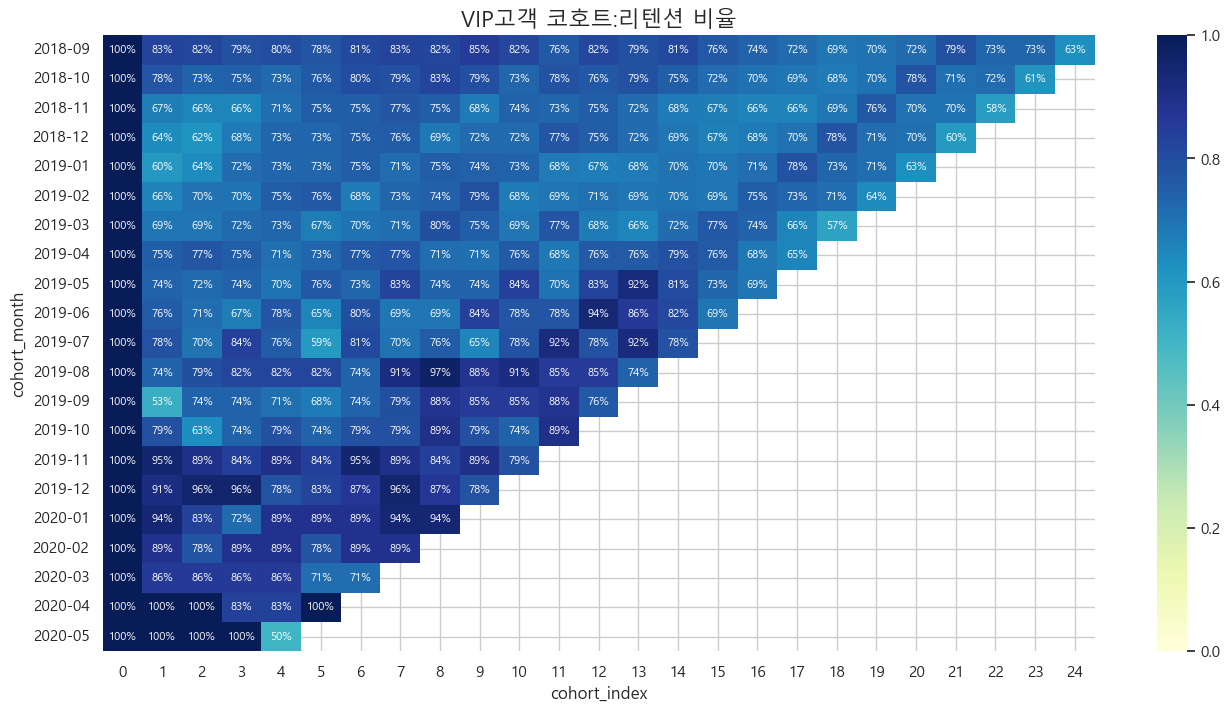

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
c3_users = rfm[rfm['Cluster'] == 3]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c3_data = df[df['customer_id'].isin(c3_users)]
# [수정] 분석 대상을 Cluster 3 데이터로 한정합니다.
target_df = c3_data.copy()

# 1. 월 단위 변환
target_df['order_month'] = target_df['t_dat'].dt.to_period('M')

# 2. 고객별 첫 구매 월 추출 (Cluster 3 내에서의 첫 구매일)
target_df['cohort_month'] = target_df.groupby('customer_id')['order_month'].transform('min')

# 3. 코호트 인덱스 계산 (몇 개월째 방문인지)
target_df['cohort_index'] = (target_df['order_month'] - target_df['cohort_month']).apply(lambda x: x.n)

# 4. 코호트 데이터 집계 (유니크 고객 수)
cohort_data = target_df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()

# 5. 피벗 테이블 생성
cohort_matrix = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')
# 첫 번째 열(Index 0)로 각 행을 나누어 잔존율 계산
cohort_size = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0)

# 시각화 시 fmt='.1%'로 설정하면 보기 편합니다.
# 6. 시각화 (유저 수 히트맵)
# 6. 시각화 (잔존율 히트맵)
plt.figure(figsize=(16, 8))
plt.title('VIP고객 코호트:리텐션 비율', fontsize=16)

# [중요] cohort_matrix 대신 retention_matrix를 사용합니다.
sns.heatmap(retention_matrix, 
            annot=True, 
            fmt='.0%',       # 2. '.1%' 대신 '.0%'를 사용하여 소수점을 없애면 공간이 확보됩니다.
            annot_kws={"size": 8}, # 3. 글자 크기를 줄입니다 (기본값은 보통 10~12).
            cmap='YlGnBu',
            vmin=0.0)
plt.show()

Cluster 3 유저들이 처음 구매한 주요 상품:
product_type_name
Sweater     6622
Trousers    5718
Dress       2753
Blouse      2079
T-shirt     1557
Jacket      1484
Top         1465
Skirt        991
Shirt        971
Bra          942
Name: count, dtype: int64


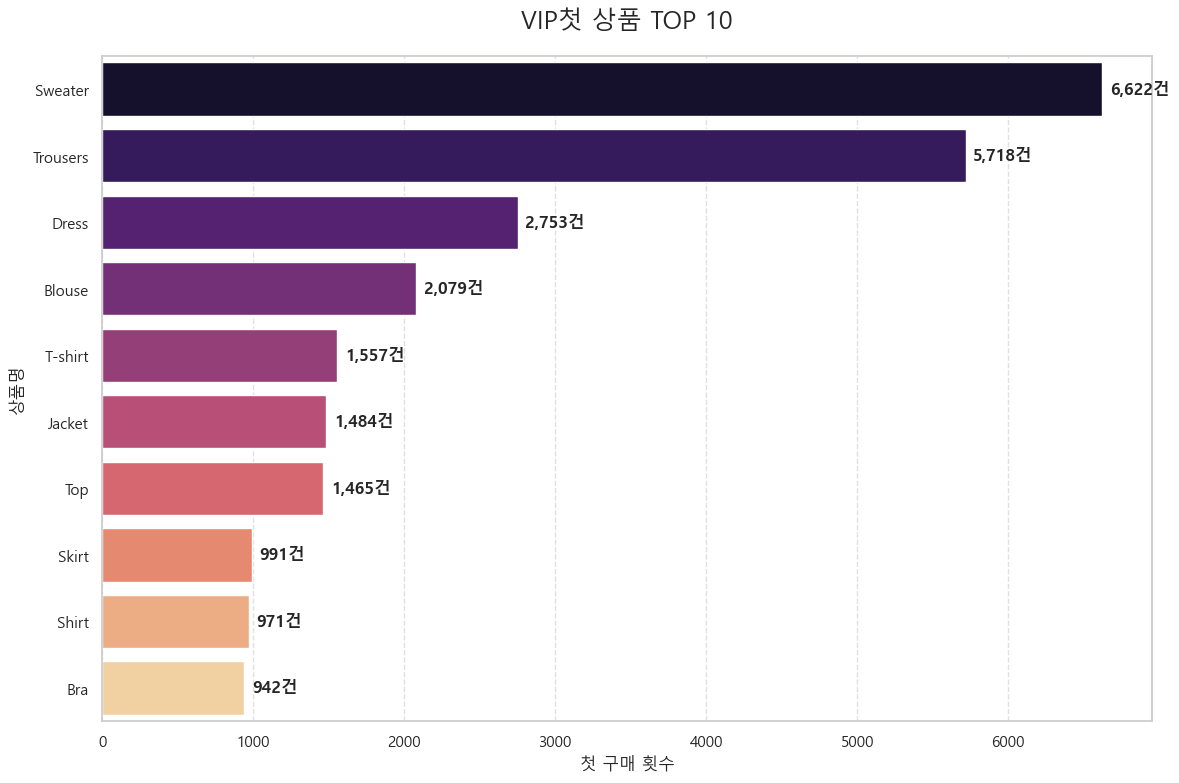

In [27]:
first_orders = target_df.sort_values('t_dat').groupby('customer_id').first()

# 2. 첫 구매 상품 비중 확인
first_product_counts = first_orders['product_type_name'].value_counts().head(10)

print("Cluster 3 유저들이 처음 구매한 주요 상품:")
print(first_product_counts)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비 (Categorical 데이터의 빈 칸을 완전히 제거)
# .head(10).copy()를 사용하여 상위 10개만 완전히 독립된 데이터로 복사합니다.
top10_plot_data = first_product_counts.head(10).reset_index()
top10_plot_data.columns = ['상품 종류', '구매 건수']

#  중요: 만약 '상품 종류'가 Categorical 타입이면 사용되지 않는 카테고리를 삭제해야 합니다.
if top10_plot_data['상품 종류'].dtype.name == 'category':
    top10_plot_data['상품 종류'] = top10_plot_data['상품 종류'].cat.remove_unused_categories()
else:
    # 일반 객체 타입이라면 명시적으로 문자열로 변환하여 잔여 정보를 없앱니다.
    top10_plot_data['상품 종류'] = top10_plot_data['상품 종류'].astype(str)

# 3. 시각화
plt.figure(figsize=(12, 8))

# order 매개변수를 추가하여 상위 10개만 그리도록 강제합니다.
barplot = sns.barplot(
    x='구매 건수', 
    y='상품 종류', 
    data=top10_plot_data, 
    palette='magma',
    order=top10_plot_data['상품 종류'] # 이 순서대로 10개만 그리라고 명령
)

# 그래프 막대 끝에 수치 표시
for p in barplot.patches:
    width = p.get_width()
    if width > 0:
        plt.text(width + 50, p.get_y() + p.get_height()/2, 
                 f'{int(width):,}건', ha='left', va='center', fontweight='bold')

plt.title('VIP첫 상품 TOP 10', fontsize=18, pad=20)
plt.xlabel('첫 구매 횟수', fontsize=12)
plt.ylabel('상품명', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

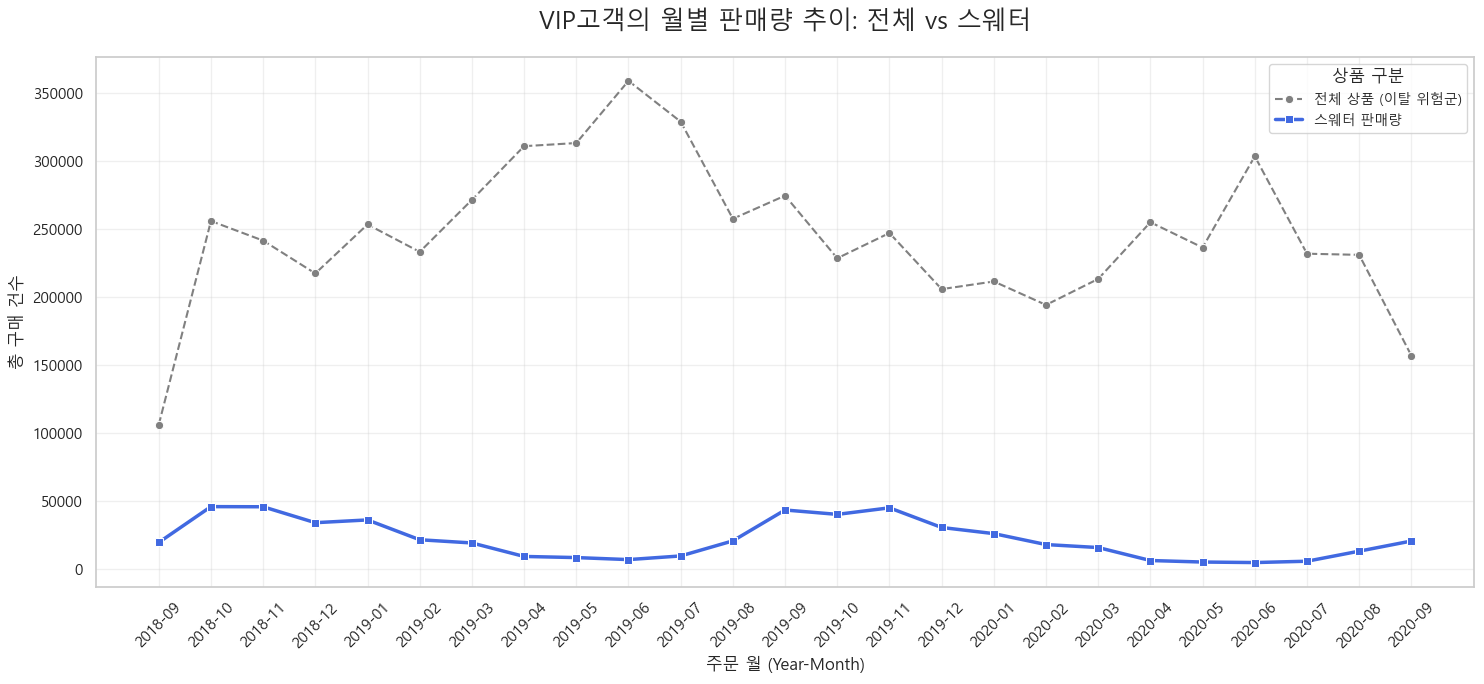

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 스웨터 데이터만 별도로 추출
sweater_df = target_df[target_df['product_type_name'] == 'Sweater'].copy()

# 2. 월별 판매량 집계 (전체 vs 스웨터)
# 'order_month'는 앞서 코호트 분석 시 생성한 Period 타입을 사용합니다.
monthly_total = target_df.groupby('order_month').size()
monthly_sweater = sweater_df.groupby('order_month').size()

# 3. 시각화
# 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15, 7))

# 전체 판매 추이 (범례 이름도 한글로 변경)
sns.lineplot(x=monthly_total.index.astype(str), y=monthly_total.values, 
             label='전체 상품 (이탈 위험군)', marker='o', linestyle='--', color='gray')

# 스웨터 판매 추이 (범례 이름도 한글로 변경)
sns.lineplot(x=monthly_sweater.index.astype(str), y=monthly_sweater.values, 
             label='스웨터 판매량', marker='s', color='royalblue', linewidth=2.5)

# --- 한글 라벨 설정 ---
plt.title('VIP고객의 월별 판매량 추이: 전체 vs 스웨터', fontsize=18, pad=20)
plt.xlabel('주문 월 (Year-Month)', fontsize=12)
plt.ylabel('총 구매 건수', fontsize=12)

plt.xticks(rotation=45) 
plt.legend(title='상품 구분', fontsize=10) # 범례 타이틀 추가
plt.grid(True, alpha=0.3)
plt.tight_layout() # 그래프 요소가 잘리지 않게 조정
plt.show()

--- 2019년 6월 Cluster 3 인기 품목 TOP 10 ---
product_type_name
Dress              54922
Trousers           37080
Shorts             28345
Vest top           26425
T-shirt            25275
Blouse             22394
Swimwear bottom    18733
Bikini top         17492
Top                16793
Skirt              13991
Name: count, dtype: int64


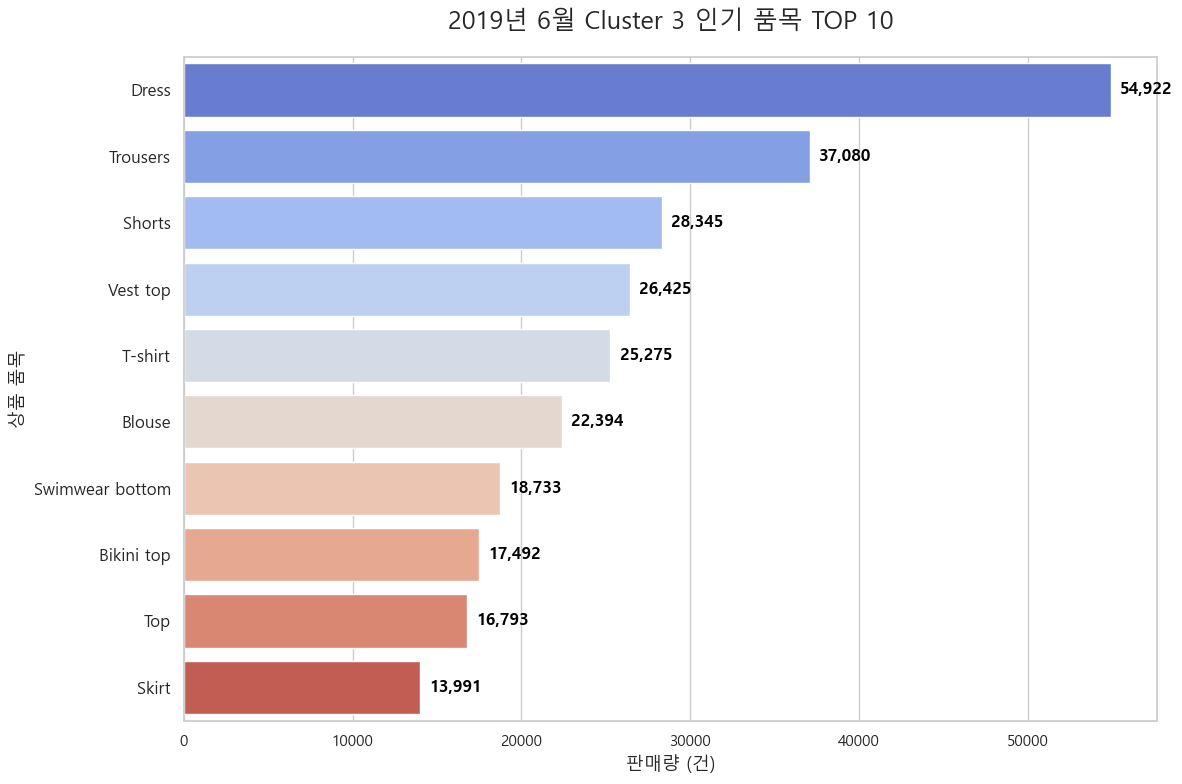

In [29]:
# 1. 2019년 6월 데이터만 필터링
june_2019_df = target_df[target_df['order_month'] == '2019-06']

# 2. 제품 타입별 판매량 집계 및 상위 5개 추출
june_top5 = june_2019_df['product_type_name'].value_counts().head(10)

# 3. 결과 출력
print("--- 2019년 6월 Cluster 3 인기 품목 TOP 10 ---")
print(june_top5)

# 4. 시각화 (선택 사항)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 이전 그래프 잔상 완전히 제거 및 캔버스 설정
plt.close('all')
plt.figure(figsize=(12, 8)) # 10개를 보여주기 적당한 높이

# 2. 데이터 추출 (이미 계산된 june_top5 사용)
# 만약 위에서 계산을 안 했다면: june_top5 = june_2019_df['product_type_name'].value_counts().head(10)

# 3. 시각화 (y축을 june_top5.index로 고정하는 것이 핵심!)
ax = sns.barplot(x=june_top5.values, 
                 y=june_top5.index, 
                 palette='coolwarm',
                 order=june_top5.index) # 이 옵션이 겹침을 막아줍니다

# 4. 그래프 꾸미기
plt.title('2019년 6월 Cluster 3 인기 품목 TOP 10', fontsize=18, pad=20)
plt.xlabel('판매량 (건)', fontsize=13)
plt.ylabel('상품 품목', fontsize=13)

# 5. 막대 끝에 숫자 표시
for i, v in enumerate(june_top5.values):
    ax.text(v + (max(june_top5.values) * 0.01), i, f'{int(v):,}', 
            va='center', fontweight='bold', color='black')

# y축 글자 크기 조정 및 여백 최적화
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

--- 2020년 6월 Cluster 3 인기 품목 TOP 10 ---
product_type_name
Dress              56643
Trousers           33121
Shorts             20960
T-shirt            19787
Vest top           17071
Blouse             15022
Top                14892
Bikini top         14282
Swimwear bottom    14016
Skirt              13456
Name: count, dtype: int64


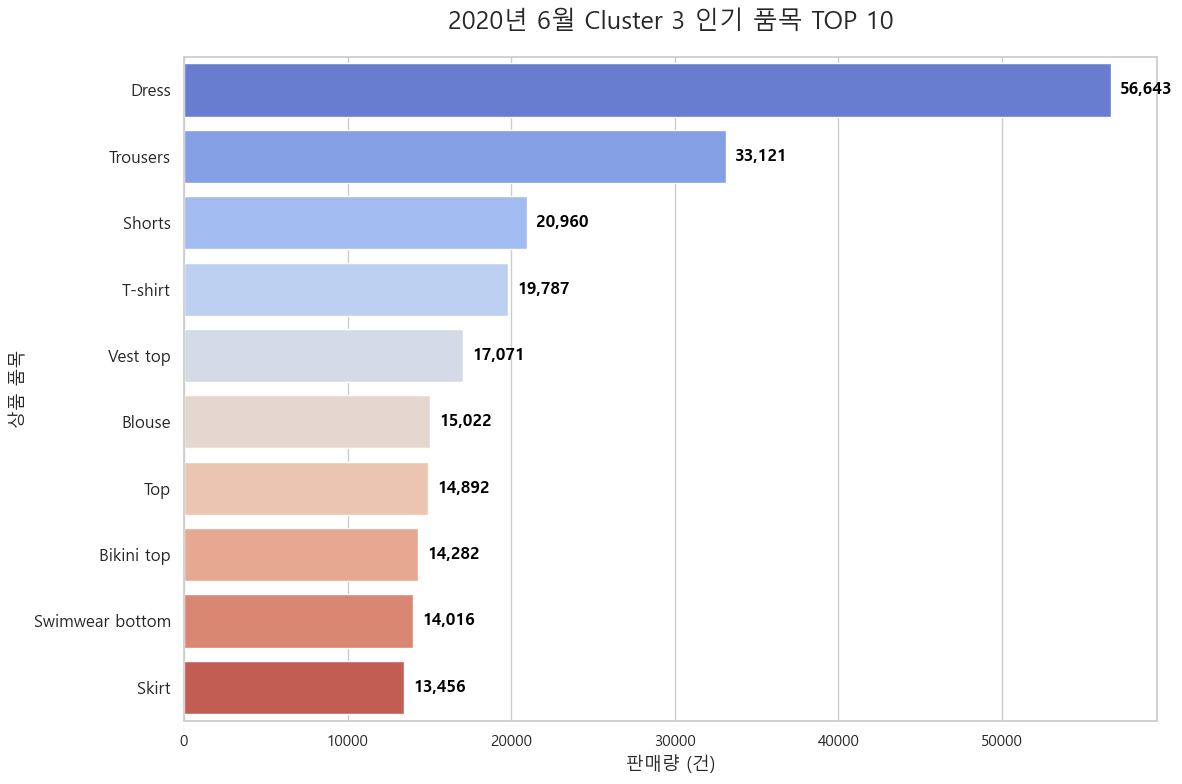

In [30]:
# 1. 2020년 6월 데이터만 필터링
june_2020_df = target_df[target_df['order_month'] == '2020-06']

# 2. 제품 타입별 판매량 집계 및 상위 10개 추출
june_top5 = june_2020_df['product_type_name'].value_counts().head(10)

# 3. 결과 출력
print("--- 2020년 6월 Cluster 3 인기 품목 TOP 10 ---")
print(june_top5)

# 4. 시각화 (선택 사항)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 이전 그래프 잔상 완전히 제거 및 캔버스 설정
plt.close('all')
plt.figure(figsize=(12, 8)) # 10개를 보여주기 적당한 높이

# 3. 시각화 (y축을 june_top5.index로 고정하는 것이 핵심!)
ax = sns.barplot(x=june_top5.values, 
                 y=june_top5.index, 
                 palette='coolwarm',
                 order=june_top5.index) # 이 옵션이 겹침을 막아줍니다

# 4. 그래프 꾸미기
plt.title('2020년 6월 Cluster 3 인기 품목 TOP 10', fontsize=18, pad=20)
plt.xlabel('판매량 (건)', fontsize=13)
plt.ylabel('상품 품목', fontsize=13)

# 5. 막대 끝에 숫자 표시
for i, v in enumerate(june_top5.values):
    ax.text(v + (max(june_top5.values) * 0.01), i, f'{int(v):,}', 
            va='center', fontweight='bold', color='black')

# y축 글자 크기 조정 및 여백 최적화
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## 과거고객생의가치

In [31]:
import pandas as pd
# 지금까지 이 고객이 우리에게 준 가치
# 0. 날짜 형식 변환 (연산 전 필수)
df['t_dat'] = pd.to_datetime(df['t_dat'])

# 1. 데이터 전체 분석 기간 계산 (2018-09-20 ~ 2020-09-22)
analysis_start = df['t_dat'].min()
analysis_end = df['t_dat'].max()
total_days = (analysis_end - analysis_start).days + 1  # 약 733일

# 2. 고객별 지표 집계
clv = df.groupby('customer_id').agg({
    'price': 'sum',
    't_dat': ['nunique', 'min', 'max']
})
clv.columns = ['총구매금액', '구매횟수', '최초구매일', '최종구매일']

# 3. 핵심 지표 계산
# 평균구매금액 (AOV)
clv['평균구매금액'] = clv['총구매금액'] / clv['구매횟수']

# 평균구매빈도 (연간 표준화)
# 전체 분석 기간(total_days) 동안의 빈도를 1년(365일) 기준으로 환산
# 고객마다 가입 시점이 다르기 때문에, 단순히 "총 구매 횟수"만 보면 먼저 가입한 고객이 유리할 수밖에 없습니다.
# 이를 해결하기 위해 이 고객이 1년(365일) 동안 활동한다면 평균적으로 몇 번 구매할까?를 계산함
clv['평균구매빈도'] = (clv['구매횟수'] / total_days) * 365

# 가입기간_년 (개별 고객의 유지 기간)
# 이 지표는 고객이 우리 서비스와 인연을 맺은 **'순수 활동 시간'**을 연 단위로 측정한 것입니다.
clv['가입기간_일'] = (clv['최종구매일'] - clv['최초구매일']).dt.days + 1
clv['가입기간_년'] = clv['가입기간_일'] / 365

# 4. LTV(고객생애가치) 계산
clv['과거고객생애가치'] = clv['가입기간_년'] * clv['평균구매금액'] * clv['평균구매빈도']

# 결과 확인
# 최종식 평균구매금액(AOV) x times 연간 구매빈도 x times 가입 기간(년)
print(f"데이터 전체 분석 기간: {total_days}일")
print(clv[['평균구매금액', '평균구매빈도', '가입기간_년', '과거고객생애가치']].head())

데이터 전체 분석 기간: 734일
                평균구매금액     평균구매빈도    가입기간_년     과거고객생애가치
customer_id                                             
0            38.290001   4.972752  1.695890   322.908863
1            66.745216  11.437330  1.800000  1374.096682
2            59.402859   3.480926  1.991781   411.854425
3            35.980000   0.497275  0.002740     0.049019
4            46.186665   2.983651  1.838356   253.334484


   Cluster     과거고객생애가치
0        0   110.675631
1        1   856.507803
2        2    13.227342
3        3  2955.018147


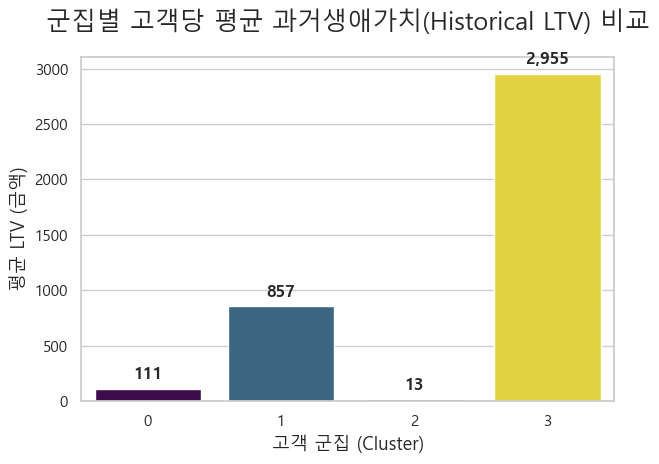

In [32]:
# 1. 계산된 LTV 데이터와 기존 RFM(Cluster 포함) 데이터 병합
# clv의 index가 customer_id이므로 reset_index()를 하거나 left_on/right_index를 활용합니다.
rfm_with_ltv = pd.merge(rfm, clv[['과거고객생애가치', '평균구매금액', '평균구매빈도', '가입기간_년']], 
                        on='customer_id', how='left')

# 2. 군집별 LTV 평균 확인 (어떤 그룹이 가장 가치 있는가?)
cluster_ltv = rfm_with_ltv.groupby('Cluster')['과거고객생애가치'].mean().reset_index()
print(cluster_ltv)

import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 8))
plt.close('all') # 잔상 제거

# 군집별 LTV 평균 시각화
ax = sns.barplot(data=cluster_ltv, x='Cluster', y='과거고객생애가치', 
                 palette='viridis', hue='Cluster', legend=False)

# 그래프 제목 및 라벨 설정
plt.title('군집별 고객당 평균 과거생애가치(Historical LTV) 비교', fontsize=18, pad=20)
plt.xlabel('고객 군집 (Cluster)', fontsize=13)
plt.ylabel('평균 LTV (금액)', fontsize=13)

# 막대 위에 수치 표시 (천 단위 콤마 포함)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), 
                textcoords='offset points', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## BG/NBD 모델,Gamma-Gamma 모델 ltv측정

In [ ]:
# # 1. RFM 지표 계산
# df['t_dat'] = pd.to_datetime(df['t_dat'])
# snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

# rfm = df.groupby('customer_id').agg(
#     Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
#     Frequency=('t_dat', 'nunique'),
#     Monetary=('price', 'sum')
# ).reset_index()
ltv_df = rfm.copy()

# 2. 값 가공 (이미 Frequency가 구매 일수/횟수라면 1을 빼서 '재구매' 횟수로 만듭니다)
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency']#재방문횟수
# 원본 데이터 df를 활용해 고객별 첫 구매일 계산
customer_first_purchase = df.groupby('customer_id')['t_dat'].min().reset_index()
customer_first_purchase.columns = ['customer_id', 'first_purchase']

# 기존 rfm 데이터프레임과 병합
ltv_df = pd.merge(rfm, customer_first_purchase, on='customer_id')

# T (Age): 첫 구매일부터 snapshot_date까지의 총 기간(일 단위)
ltv_df['T'] = (snapshot_date - ltv_df['first_purchase']).dt.days

# LTV 모델용 Recency: 첫 구매일부터 마지막 구매일까지의 기간 (lifetimes 모델 기준)
# 주의: 기존 Recency(기준일 - 마지막 구매일)와는 다른 개념입니다.
ltv_df['recency_ltv'] = ltv_df['T'] - ltv_df['Recency']

# Frequency: 재방문 횟수 (전체 방문횟수 - 1)
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1

# Monetary: 1회 방문당 평균 구매 금액
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency']
from lifetimes import BetaGeoFitter, GammaGammaFitter

# [단계 1] BG/NBD 모델 학습 앞으로 몇 번 더 올지를 예측
bgf = BetaGeoFitter(penalizer_coef=0.01)
# lifetimes 모델 공식 기준: frequency_ltv, recency_ltv, T 사용
bgf.fit(ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'])

# [단계 2] Gamma-Gamma 모델 학습 (수익성 예측)한 번 올때 얼마를 쓸지를 예측
returning_customers = ltv_df[ltv_df['frequency_ltv'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers['frequency_ltv'], returning_customers['monetary_avg'])

# [단계 3] 향후 365일 예상 LTV(CLV) 계산(향후 365일 동안의 기대 수익을 고객별로 예측)
ltv_df['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'], ltv_df['monetary_avg'],
    time=365, discount_rate=0
)


In [ ]:
from lifetimes import BetaGeoFitter, GammaGammaFitter

# [단계 1] BG/NBD 모델 학습 앞으로 몇 번 더 올지를 예측
bgf = BetaGeoFitter(penalizer_coef=0.01)
# lifetimes 모델 공식 기준: frequency_ltv, recency_ltv, T 사용
bgf.fit(ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'])

# [단계 2] Gamma-Gamma 모델 학습 (수익성 예측)한 번 올때 얼마를 쓸지를 예측
returning_customers = ltv_df[ltv_df['frequency_ltv'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers['frequency_ltv'], returning_customers['monetary_avg'])

# [단계 3] 향후 365일 예상 LTV(CLV) 계산(향후 365일 동안의 기대 수익을 고객별로 예측)
ltv_df['predicted_clv'] = ggf.customer_lifetime_value()
    bgf,
    ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'], ltv_df['monetary_avg'],
    time=365, discount_rate=0

## Gamma-Gamma 모델의 신뢰도평가

- Gamma-Gamma 모델은 상관관계가 없어야함

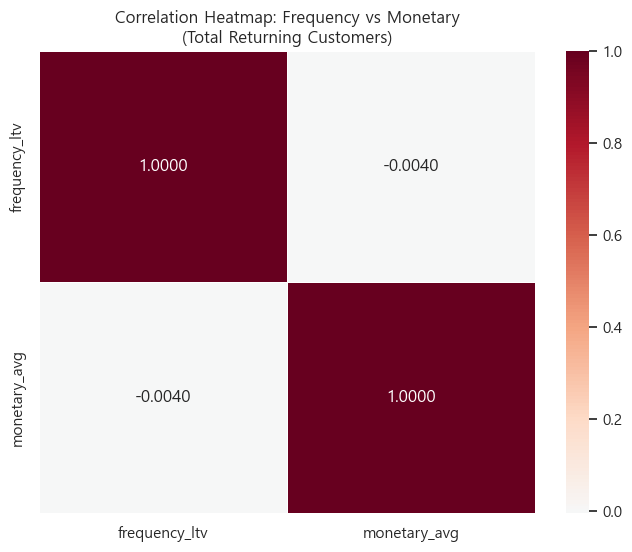

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 재구매 고객(Frequency > 0) 데이터만 추출
returning_customers = ltv_df[ltv_df['frequency_ltv'] > 0]

# 2. 상관계수 계산
corr_matrix = returning_customers[['frequency_ltv', 'monetary_avg']].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,          # 숫자 표시
            fmt='.4f',           # 소수점 4자리까지 (0.004 확인용)
            cmap='RdBu_r',       # 붉은색(음수) ~ 파란색(양수) 컬러맵
            center=0,            # 0을 기준으로 색상 지정
            linewidths=0.5)      # 셀 사이 구분선

plt.title('Correlation Heatmap: Frequency vs Monetary\n(Total Returning Customers)')
plt.show()

병합 후 컬럼 목록: Index(['customer_id', 'Recency', 'Frequency', 'Monetary', 'first_purchase',
       'T', 'recency_ltv', 'frequency_ltv', 'monetary_avg', 'predicted_clv',
       'Cluster'],
      dtype='object')
데이터 샘플:
    customer_id  Recency  Frequency     Monetary first_purchase    T  \
0            0       18         10   382.899994     2018-12-27  636   
1            1       77         23  1535.140015     2018-09-21  733   
2            2        8          7   415.820007     2018-09-20  734   
3            3      472          1    35.980000     2019-06-09  472   
4            4       42          6   277.119995     2018-10-12  712   

   recency_ltv  frequency_ltv  monetary_avg  predicted_clv  Cluster  
0          618              9     38.290001    5180.733545        0  
1          656             22     66.745216   18231.609140        1  
2          726              6     59.402859    4843.753646        0  
3            0              0     35.980000            NaN        2  
4       

,predicted_clv,Frequency,Monetary,Recency,user_count
Cluster,,,,,
0,3990.496901,4.141481,200.952103,127.564804,708223
1,12837.165227,18.131518,1019.053345,56.792164,210709
2,800.990900,1.791610,97.952927,536.825626,406684
3,38964.810497,42.032065,3189.160889,29.652834,35303


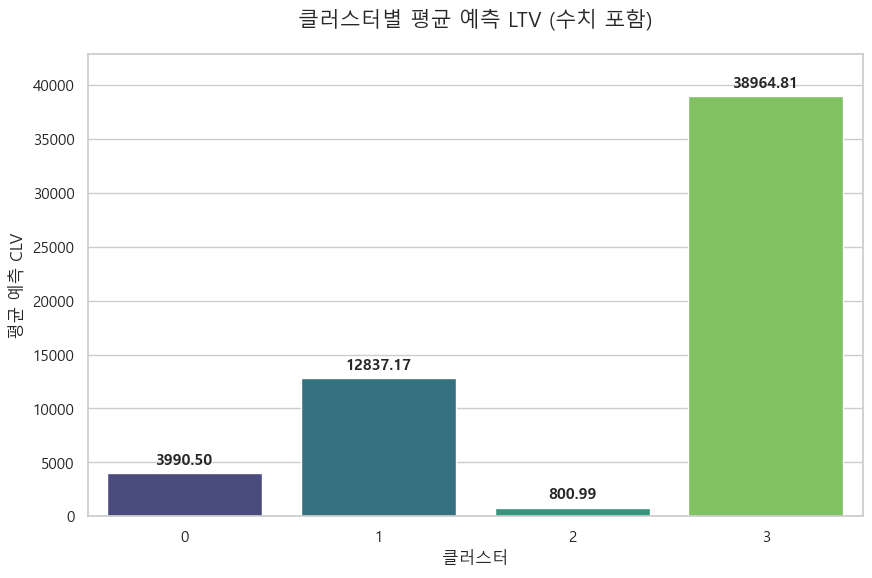

In [ ]:
if 'Cluster' in ltv_df.columns:
    ltv_df = ltv_df.drop(columns=['Cluster'])

# 2. rfm에서 필요한 컬럼만 가져와서 병합
# merge 방식(how='left')을 명시하여 ltv_df 기준 데이터가 유실되지 않게 합니다.
final_df = pd.merge(ltv_df, rfm[['customer_id', 'Cluster']], on='customer_id', how='left')

# 3. 데이터 확인 (여기서 Cluster가 있는지 눈으로 확인!)
print("병합 후 컬럼 목록:", final_df.columns)
print("데이터 샘플:\n", final_df.head())

# 4. 이제 그룹바이 실행
cluster_stats = final_df.groupby('Cluster').agg({
    'predicted_clv': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Recency': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'user_count'})

display(cluster_stats)

import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

# 1. 그래프 그리기 (barplot 객체를 변수에 담습니다)
ax = sns.barplot(x=cluster_stats.index, y='predicted_clv', data=cluster_stats, palette='viridis')

# 2. 막대 위에 수치 표시하기
for p in ax.patches:
    # 각 막대의 수치를 소수점 둘째자리까지 포맷팅 (정수를 원하면 {int(p.get_height())} 사용)
    value = f'{p.get_height():.2f}'
    
    # 텍스트 배치 (x좌표, y좌표, 내용, 정렬 등)
    ax.annotate(value, 
                (p.get_x() + p.get_width() / 2., p.get_height()), # 막대 중앙 상단 좌표
                ha='center', va='center', 
                xytext=(0, 9), # 막대에서 위로 9포인트 정도 띄움
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('클러스터별 평균 예측 LTV (수치 포함)', fontsize=15, pad=20)
plt.xlabel('클러스터', fontsize=12)
plt.ylabel('평균 예측 CLV', fontsize=12)

# y축 범위를 수치 표시 공간 확보를 위해 약간 넓힘
plt.ylim(0, cluster_stats['predicted_clv'].max() * 1.1) 

plt.show()

## 우수고객 코호트

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
c1_users = rfm[rfm['Cluster'] == 1]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c1_data = df[df['customer_id'].isin(c1_users)]

# [수정] 분석 대상을 Cluster 1 데이터로 한정합니다.
target_df = c1_data.copy()

# 1. 월 단위 변환
target_df['order_month'] = target_df['t_dat'].dt.to_period('M')

# 2. 고객별 첫 구매 월 추출 (Cluster 3 내에서의 첫 구매일)
target_df['cohort_month'] = target_df.groupby('customer_id')['order_month'].transform('min')

# 3. 코호트 인덱스 계산 (몇 개월째 방문인지)
target_df['cohort_index'] = (target_df['order_month'] - target_df['cohort_month']).apply(lambda x: x.n)

# 4. 코호트 데이터 집계 (유니크 고객 수)
cohort_data = target_df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()

# 5. 피벗 테이블 생성
cohort_matrix = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

# 1. 이전 설정 초기화 및 캔버스 설정
plt.close('all')
# 셀이 가로로 길기 때문에 너비를 충분히 확보합니다.
plt.figure(figsize=(25, 15)) 

# 2. 히트맵 그리기
# 원본 데이터(cohort_matrix)를 그대로 사용합니다.
ax = sns.heatmap(cohort_matrix, 
                 annot=True, 
                 fmt=',.0f',       # 천 단위 콤마 추가 (예: 122,997)
                 cmap='YlGnBu', 
                 linewidths=.5,    # 셀 사이 간격 추가 (글자 겹침 완화)
                 cbar_kws={'label': '고객 수 (명)'},
                 annot_kws={"size": 8, "weight": "bold"}) # 글자 크기를 줄이고 굵게 설정

# 3. 디자인 디테일 수정
plt.title('월별 코호트 분석: 우수 고객 수 현황', fontsize=22, pad=30)
plt.xlabel('코호트 인덱스 (가입 후 개월 차)', fontsize=15)
plt.ylabel('가입 월 (Cohort Month)', fontsize=15)

# x축 라벨이 잘 보이도록 조정
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

## 연관분석 이탈위험고객

In [ ]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
# apriori 대신 fpgrowth 사용 (속도가 훨씬 빠르고 메모리 사용량이 적음)
# 1. 한 전표(customer_id)당 구매한 상품 리스트를 원-핫 인코딩 형태로 변환
# 1. Cluster 0 고객 아이디만 추출
c0_users = rfm[rfm['Cluster'] == 0]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c0_data = df[df['customer_id'].isin(c0_users)]

basket = (c0_data.groupby(['customer_id', 'product_type_name'])['product_type_name']
          .count().unstack().reset_index().fillna(0)
          .set_index('customer_id'))

# 2. 1 이상은 1로, 0은 0으로 변환 (구매 여부만 판단)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets = basket.applymap(encode_units)

frequent_itemsets = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)#전체거래중 5%이상같이 사야함
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules.sort_values('lift', ascending=False)

# antecedents  이걸산사람이
# consequents  이것도 사더라
# antecedent support a의 인기(단독으로 구매한 비율)
# consequent support b의 인기(단독으로 구매한 비율)
# support 지지도 a와b를 동시에 구매한비율
# confidence a를 산 사람이 b도 살 확률
# lift 1보다 크면 유의미(연관성이 높다)
# leverage 0이면 독립,양수면 연관성있음
# conviction(확신성) 1이면관계없음,값이 커질수록 a를 샀는데 b를 안살확률이 낮음
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic' 

plt.figure(figsize=(10, 6))
sns.scatterplot(x='support', y='confidence', hue='lift', size='lift', data=rules)
plt.title('Cluster 0 연관 규칙 산점도 (Support vs Confidence)')
plt.xlabel('지지도 (Support)')
plt.ylabel('신뢰도 (Confidence)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

import networkx as nx

# 상위 20개 규칙만 추출 (너무 많으면 그래프가 복잡해짐)
sub_rules = rules.sort_values('lift', ascending=False).head(20)

G = nx.DiGraph()

# 노드와 에지 추가
for i, row in sub_rules.iterrows():
    # frozenset을 문자열로 변환
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

# 그래프 그리기
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1)  # 노드 간의 간격 조절
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=10, font_family='Malgun Gothic', edge_color="gray", 
        arrowsize=20, width=[d['weight']/2 for u, v, d in G.edges(data=True)])

plt.title('Cluster 0 주요 연관 상품 네트워크', size=15)
plt.show()

- 이탈위험고객의 연관규칙(색조합)

In [ ]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 1. 한 전표(customer_id)당 구매한 상품 리스트를 원-핫 인코딩 형태로 변환
baskets = (c0_data.groupby(['customer_id', 'colour_group_name'])['colour_group_name']
          .count().unstack().reset_index().fillna(0)
          .set_index('customer_id'))

# 2. 1 이상은 1로, 0은 0으로 변환 (구매 여부만 판단)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets = baskets.applymap(encode_units)

frequent_itemsets = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)
result = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 결과 확인 (가장 연관성이 높은 순서대로)
result .sort_values('lift', ascending=False)

import networkx as nx
import matplotlib.pyplot as plt 

# 한글 깨짐 방지 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False
# 상위 20개 규칙만 추출 (너무 많으면 그래프가 복잡해짐)
sub_rules = result.sort_values('lift', ascending=False).head(20)

G = nx.DiGraph()

# 노드와 에지 추가
for i, row in sub_rules.iterrows():
    # frozenset을 문자열로 변환
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

# 그래프 그리기
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1)  # 노드 간의 간격 조절
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=10, font_family='Malgun Gothic', edge_color="gray", 
        arrowsize=20, width=[d['weight']/2 for u, v, d in G.edges(data=True)])

plt.title('Cluster 0 주요 연관 상품 네트워크', size=15)
plt.show()

- 특정옷을 사는데 어떤 색상을 같이 샀는가(연관규칙)

In [ ]:

import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. '옷 종류' 데이터와 '색상' 데이터를 각각 원-핫 인코딩하여 옆으로 합치기
# 고객별로 어떤 옷 종류를 샀는지 체크
garment_basket = c0_data.groupby(['customer_id', 'product_type_name'])['product_type_name'].count().unstack().fillna(0)

# 고객별로 어떤 색상을 샀는지 체크
color_basket = c0_data.groupby(['customer_id', 'colour_group_name'])['colour_group_name'].count().unstack().fillna(0)

# 두 테이블을 옆으로 합침 (고객 ID 기준)
combined_basket = pd.concat([garment_basket, color_basket], axis=1)

# 2. 샀으면 1, 안 샀으면 0으로 변환
basket_sets = combined_basket.applymap(lambda x: 1 if x > 0 else 0)

# 3. 연관 규칙 분석 실행 (FP-Growth) 3%
frequent_itemsets = fpgrowth(basket_sets, min_support=0.03, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 4. 결과 필터링
# antecedents에는 옷종류,consequents에는 색상정보
# a사는 사람은b색상을 선호한다
# 수정된 단계 4: 조건(antecedents)에는 오직 '옷 종류'만 있고, 결과(consequents)에는 '색상'만 있는 경우
filtered_rules = rules[
    # 1. 조건절(antecedents)의 모든 아이템이 garment_basket 컬럼(옷 종류)에 속해야 함
    rules['antecedents'].apply(lambda x: all(item in garment_basket.columns for item in x)) & 
    
    # 2. 결과절(consequents)의 모든 아이템이 color_basket 컬럼(색상)에 속해야 함
    rules['consequents'].apply(lambda x: all(item in color_basket.columns for item in x))
]

filtered_rules.sort_values('lift', ascending=False)

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. 데이터 준비: 옷 종류 열과 색상 열을 각각 만들어서 옆으로 합치기
garment_basket = c0_data.groupby(['customer_id', 'product_type_name'])['product_type_name'].count().unstack().fillna(0)
color_basket = c0_data.groupby(['customer_id', 'colour_group_name'])['colour_group_name'].count().unstack().fillna(0)

# 두 테이블 결합 (고객 한 명이 산 옷 종류와 색상이 한 행에 나열됨)
combined_basket = pd.concat([garment_basket, color_basket], axis=1)
basket_sets = combined_basket.applymap(lambda x: 1 if x > 0 else 0)

# 2. 연관 규칙 분석 (메모리 효율을 위해 fpgrowth 사용)
frequent_itemsets = fpgrowth(basket_sets, min_support=0.03, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 3. 시각화용 데이터 필터링 (원인: 옷 종류 -> 결과: 색상 인 경우만 추출)
# 이 필터를 거쳐야 '검정색->하얀색' 같은 결과가 빠지고 '상의->검정색' 같은 결과만 남습니다.
viz_rules = rules[
    rules['antecedents'].apply(lambda x: any(item in garment_basket.columns for item in x)) &
    rules['consequents'].apply(lambda x: any(item in color_basket.columns for item in x))
].sort_values('lift', ascending=False).head(20)

# 4. 네트워크 그래프 시각화
G = nx.DiGraph()

for i, row in viz_rules.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

plt.figure(figsize=(15, 10))
# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic' 

pos = nx.spring_layout(G, k=1.5) # 노드 간격을 조금 더 넓게 설정
nx.draw(G, pos, with_labels=True, 
        node_size=5000, 
        node_color="lightcoral", # 색상 구분을 위해 변경
        font_size=10, 
        edge_color="gray", 
        arrowsize=30, 
        width=[d['weight'] for u, v, d in G.edges(data=True)])

plt.title('Cluster 0: 옷 종류별 연관 구매 색상 네트워크', size=20)
plt.show()

## 봄,여름/가을,겨울